# Importing Packages and Configuring
- from textbook

In [1]:
import pandas as pd
import numpy as np

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for better display in Jupyter
%matplotlib inline

# Set default figure size for all plots (width, height in inches)
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 5)  # Larger default size
matplotlib.rcParams['figure.dpi'] = 100          # Resolution
matplotlib.rcParams['font.size'] = 11            # Default font size

# Configure Seaborn style
sns.set_palette("deep")                          # Colorblind-friendly palette
sns.set_context("notebook")                      # Appropriate scaling

#for geospacial plotting
import warnings
# Suppress all non-critical warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
import geopandas 
import folium
import geodatasets

# Data quality check / Loading

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.** An example is given below.

## Exploring Initial Data
*By Grace Gormley*

### Importing each dataset

In [2]:
#Making my divvy dataset from 2024-2025
import glob #gonna be honest, I got this from chat so I dont need to do it one by one (i'm combining each month from 12/25 to 1/24)

files = glob.glob("/Users/gracegormley/Desktop/Stat 303-1/project/divvy 2024-2025/*.csv")   # grabs all CSVs in the folder

dfs = []                                      # empty list to store DataFrames
for f in files:
    dfs.append(pd.read_csv(f))

divvy = pd.concat(dfs, ignore_index=True)

In [3]:
#make sure they're in chronological order
divvy["started_at"] = pd.to_datetime(divvy["started_at"], format="mixed")
divvy = divvy.sort_values(by="started_at")

In [4]:
#Importing my extra datasets
traffic = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/Chicago_Traffic_Tracker_-_Congestion_Estimates_by_Segments_20251125.csv')
CTA_riders = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_-_Ridership_-_Daily_Boarding_Totals_20251125.csv')
bus_stops = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_BusStops_20251125.csv')
L_stops = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/CTA_-_System_Information_-_List_of_\'L\'_Stops_20251125.csv')
population = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/ACS_5_Year_Data_by_Community_Area.csv') #this isn't from chicago, since they organize pop by zip code. Someone already sorted them, so I'm using their data: https://www.kaggle.com/datasets/aniket0712/acs-5-year-data-by-community-area/code 
bike_stations = pd.read_csv('/Users/gracegormley/Desktop/Stat 303-1/project/Divvy_Bicycle_Stations_20251201.csv')

### Taking a look at each dataset

In [5]:
#Printing the head of each dataset to get an idea of the contents

In [6]:
divvy.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member


In [7]:
traffic.head()

,SEGMENTID,STREET,DIRECTION,FROM_STREET,TO_STREET,LENGTH,STREET_HEADING,COMMENTS,START_LONGITUDE,START_LATITUDE,END_LONGITUDE,END_LATITUDE,CURRENT_SPEED,LAST_UPDATED
0,1284,Chicago,WB,Lake Shore Dr,Michigan,0.370000,E,NaN,-87.617048,41.896936,-87.624241,41.896835,-1,2011-08-10 00:00:00.0
1,951,Washington,WB,Kedzie,Schraeder,0.280000,W,NaN,-87.706169,41.882932,-87.711747,41.882818,-1,2010-07-21 14:51:00.0
2,750,Elston,SE,Milwaukee,Austin,0.330000,N,NaN,-87.783224,41.992665,-87.778073,41.989905,-1,2010-07-21 14:51:10.0
3,1164,Harlem,SB,Ogden,Pershing,0.173023,S,Outside City Limits,-87.802922,41.823751,-87.803025,41.821245,-1,2010-07-21 14:51:15.0
4,1122,127th,EB,Western,I-57 Expy,0.907892,W,Outside City Limits,-87.680077,41.662512,-87.662540,41.662850,-1,2010-07-21 14:51:06.0


In [8]:
CTA_riders.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,01/01/2001,U,"297,192","126,455","423,647"
1,01/02/2001,W,"780,827","501,952","1,282,779"
2,01/03/2001,W,"824,923","536,432","1,361,355"
3,01/04/2001,W,"870,021","550,011","1,420,032"
4,01/05/2001,W,"890,426","557,917","1,448,343"


In [9]:
bus_stops.tail(70)

,the_geom,SYSTEMSTOP,STREET,CROSS_ST,DIR,POS,ROUTESSTPG,OWLROUTES,CITY,PUBLIC_NAM
10690,POINT (-87.74481606799998 41.862335599000005),"10,258",CICERO,14TH STREET,SB,NS,54,NaN,CICERO,Cicero & 14th Street
10691,POINT (-87.628356 41.89926400000002),"5,375",STATE,DELAWARE,SB,NS,36,NaN,CHICAGO,State & Delaware
10692,POINT (-87.654837999 41.96342100099997),"1,050",SHERIDAN,SUNNYSIDE,SB,FS,151,NaN,CHICAGO,Sheridan & Sunnyside
10693,POINT (-87.68103544299998 41.828731903000005),"4,432",35TH/ARCHER,ORANGE LINE STATION,SWB,TERM,35,NaN,CHICAGO,35th/Archer Orange Line Station
10694,POINT (-87.5400057 41.65944309499997),"7,297",AVENUE O,130TH STREET,SB,NS,30,NaN,CHICAGO,Avenue O & 130th Street
...,...,...,...,...,...,...,...,...,...,...
10755,POINT (-87.69960900000001 42.02665914200003),"14,738",DODGE,OAKTON,SB,NS,93,NaN,EVANSTON,Dodge & Oakton
10756,POINT (-87.714284169 41.933375263000016),"5,563",MILWAUKEE,WISNER,NWB,NS,56,NaN,CHICAGO,Milwaukee & Wisner
10757,POINT (-87.81891211099997 42.00458322200001),"9,910",NORTHWEST HWY,OVERHILL,NWB,FS,68,NaN,CHICAGO,Northwest Hwy & Overhill
10758,POINT (-87.67733964000001 42.053723761000015),"17,295",SHERIDAN,FOSTER,SB,FS,201,NaN,EVANSTON,Sheridan & Foster


In [10]:
L_stops.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,False,False,False,True,False,"(41.857908, -87.669147)"
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,False,False,False,False,True,"(41.829353, -87.680622)"
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,False,False,False,False,False,"(41.831677, -87.625826)"


In [11]:
population.head()

,ACS Year,Community Area,"Under $25,000","$25,000 to $49,999","$50,000 to $74,999","$75,000 to $125,000","$125,000 +",Male 0 to 17,Male 18 to 24,Male 25 to 34,...,White,Black or African American,American Indian or Alaska Native,Asian,Native Hawaiian or Pacific Islander,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID
0,2023,ALBANY PARK,1269,1916,1801,2306,3379,4799,2955,4513,...,21496,2228,759,7124,1,7888,8334,16115,21108,2023_ALBANY PARK
1,2023,ARCHER HEIGHTS,223,752,441,795,739,1927,732,1102,...,6232,10,108,679,0,3705,3142,2043,11097,2023_ARCHER HEIGHTS
2,2023,ARMOUR SQUARE,701,798,370,637,597,1300,487,871,...,2556,1487,107,8402,61,212,325,2226,565,2023_ARMOUR SQUARE
3,2023,ASHBURN,797,1351,1985,3014,2735,5150,1964,2881,...,11297,18124,697,436,0,7772,4517,3774,19917,2023_ASHBURN
4,2023,AUBURN GRESHAM,2541,2451,1592,2202,1850,5803,1836,2964,...,760,43414,119,399,0,993,798,491,1577,2023_AUBURN GRESHAM


In [12]:
bike_stations.head()

,ID,Station Name,Short Name,Total Docks,Docks in Service,Status,Latitude,Longitude,Location
0,1859717767703464460,Kedzie Ave & Redfield Dr,CHI01795,15,15,In Service,41.765230,-87.703160,POINT (-87.70316 41.76523)
1,1861588043429399408,McCormick Blvd & Devon Ave,CHI01881,11,11,In Service,41.997200,-87.711050,POINT (-87.71105 41.9972)
2,a3af1767-a135-11e9-9cda-0a87ae2ba916,Broadway & Granville Ave,CHI00563,23,23,In Service,41.994780,-87.660285,POINT (-87.6602845349 41.9947796884)
3,a3aa91f4-a135-11e9-9cda-0a87ae2ba916,Greenview Ave & Diversey Pkwy,CHI00382,15,15,In Service,41.932590,-87.665936,POINT (-87.665936350822 41.932589634298)
4,a3aa9732-a135-11e9-9cda-0a87ae2ba916,Loomis St & Lexington St,CHI00238,20,20,In Service,41.872229,-87.661364,POINT (-87.661363855004 41.87222873224)


### Finding missing values

In [13]:
divvy.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    2155418
start_station_id      2155418
end_station_name      2236017
end_station_id        2236017
start_lat                   0
start_lng                   0
end_lat                 12288
end_lng                 12288
member_casual               0
dtype: int64

In [14]:
traffic.isnull().sum()

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1032
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
dtype: int64

In [15]:
CTA_riders.isnull().sum()

service_date      0
day_type          0
bus               0
rail_boardings    0
total_rides       0
dtype: int64

In [16]:
bus_stops.isnull().sum()

the_geom         0
SYSTEMSTOP       0
STREET           0
CROSS_ST         0
DIR              0
POS              0
ROUTESSTPG       4
OWLROUTES     8602
CITY             1
PUBLIC_NAM       0
dtype: int64

In [17]:
L_stops.isnull().sum()

STOP_ID                     0
DIRECTION_ID                0
STOP_NAME                   0
STATION_NAME                0
STATION_DESCRIPTIVE_NAME    0
MAP_ID                      0
ADA                         0
RED                         0
BLUE                        0
G                           0
BRN                         0
P                           0
Y                           0
Pnk                         0
O                           0
Location                    0
dtype: int64

In [18]:
population.isnull().sum()

ACS Year                               0
Community Area                         0
Under $25,000                          0
$25,000 to $49,999                     0
$50,000 to $74,999                     0
$75,000 to $125,000                    0
$125,000 +                             0
Male 0 to 17                           0
Male 18 to 24                          0
Male 25 to 34                          0
Male 35 to 49                          0
Male 50 to 64                          0
Male 65+                               0
Female 0 to 17                         0
Female 18 to 24                        0
Female 25 to 34                        0
Female 35 to 49                        0
Female 50 to 64                        0
Female 65 +                            0
Total Population                       0
White                                  0
Black or African American              0
American Indian or Alaska Native       0
Asian                                  0
Native Hawaiian 

### Visualizing the neigborhoods (from textbook)

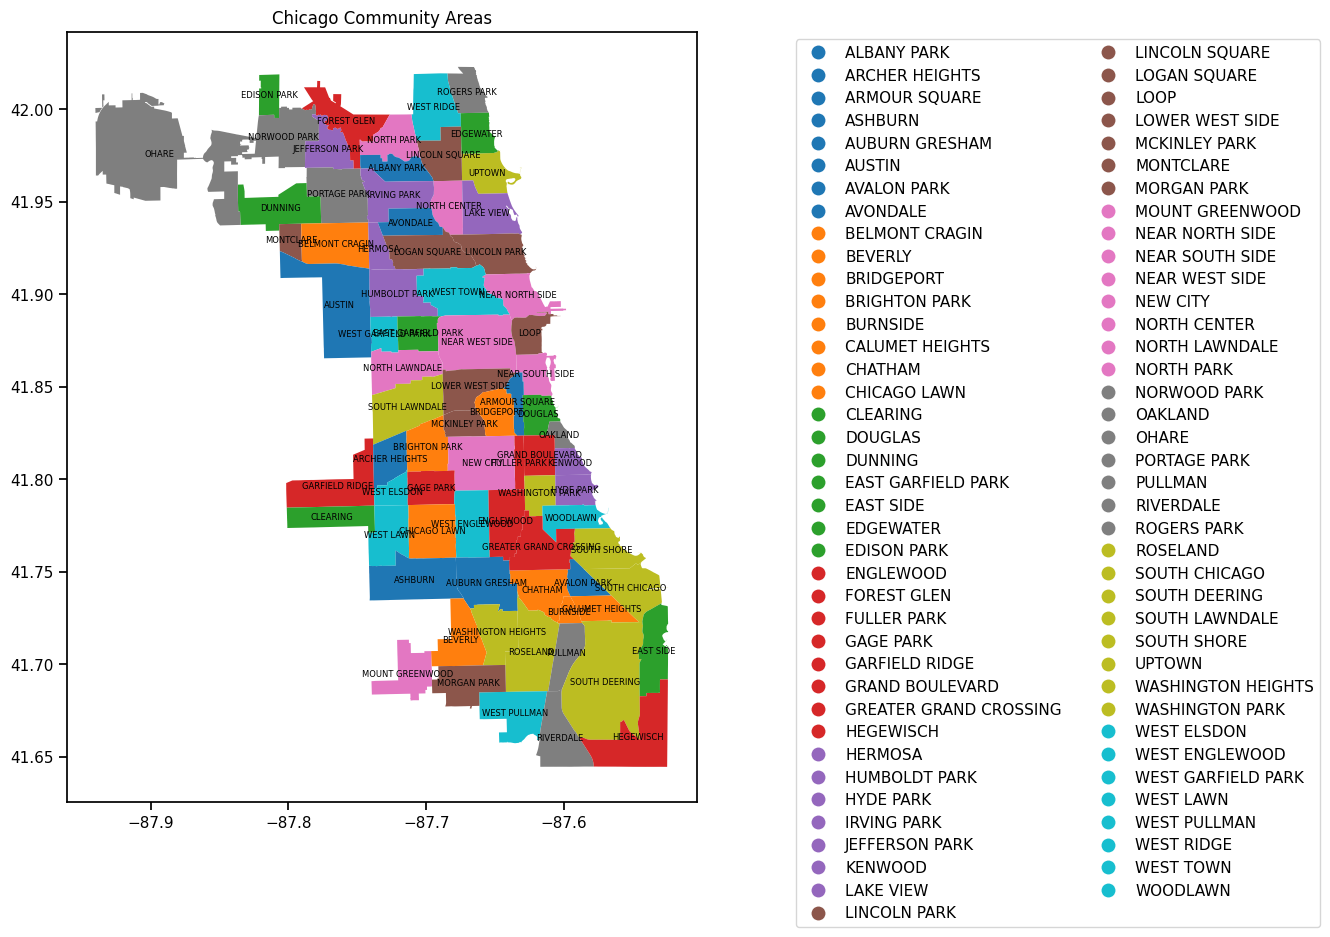

In [19]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 10))

# Plot your GeoDataFrame
chicago = gpd.read_file(r'/Users/gracegormley/Desktop/Stat 303-1/project/Boundaries - Community Areas_20251127/geo_export_a0f75e4e-d093-4b60-9319-7b3e6e34a0ad.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})
# Add community labels
for idx, row in chicago.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(
        x, y,
        row['community'],
        fontsize=6,
        ha='center',
        va='center'
    )

# Add title (optional)
plt.title('Chicago Community Areas');

# Data Preparation and Cleaning 
*By Grace Gormley*

### Assigning neighborhoods to Divvy, Traffic and Bike Stations

In [20]:
#Okay, for this part, I had chat explain the workflow to me, since I am unfamiliar with shapefile objects. Code is copied over and modified for my datasets

    #Step 1 (since we already have shapefile as geospacial object): convert dataframe
from shapely.geometry import Point
gdf_points = gpd.GeoDataFrame(divvy, geometry = gpd.points_from_xy(divvy.start_lng, divvy.start_lat), crs = "EPSG:4326")

In [21]:
    #Step 2: Making sure they have same coordinate system
print(chicago.crs)
print(gdf_points.crs)

    #Step 3: Now I assign each row to its neighborhood
divvy_nb = gpd.sjoin(gdf_points, chicago, how="left", predicate="within")

EPSG:4326
EPSG:4326


In [22]:
divvy_nb.head()
#YAYYYY

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
3486147,6A9D809ABDF70617,electric_bike,2024-01-01 00:00:39,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.950000,-87.650000,41.929546,-87.643118,member,POINT (-87.65 41.95),5.0,6.0,LAKE VIEW,6,8.721480e+07,51973.096868
3491360,26B9F6E416A68EBA,electric_bike,2024-01-01 00:00:50,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual,POINT (-87.62 41.9),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952
3486040,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:00:52,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.900000,-87.620000,41.900000,-87.620000,casual,POINT (-87.62 41.9),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952
3467452,0D9E85F804C85828,electric_bike,2024-01-01 00:00:53,2024-01-01 00:22:30,Clinton St & Madison St,TA1305000032,NaN,NaN,41.881909,-87.641296,41.890000,-87.620000,member,POINT (-87.6413 41.88191),27.0,28.0,NEAR WEST SIDE,28,1.584925e+08,53003.592941
3410785,56F5C3ED5178C131,classic_bike,2024-01-01 00:01:01,2024-01-01 00:24:12,LaSalle St & Illinois St,13430,Indiana Ave & Roosevelt Rd,SL-005,41.890762,-87.631697,41.867888,-87.623041,member,POINT (-87.6317 41.89076),7.0,8.0,NEAR NORTH SIDE,8,7.667590e+07,57293.164952


In [23]:
#I'll do that with Traffic and bike stations (clean ones)
gdf_points1 = gpd.GeoDataFrame(traffic, geometry = gpd.points_from_xy(traffic['START_LONGITUDE'], traffic[' START_LATITUDE']), crs = "EPSG:4326") #dumb space before lat :\ this took me like 15 minutes to find but oh well :)
traffic = gpd.sjoin(gdf_points1, chicago, how="left", predicate="within")

In [ ]:
gdf_points4 = gpd.GeoDataFrame(bike_stations, geometry = gpd.points_from_xy(bike_stations['Longitude'], bike_stations['Latitude']), crs = "EPSG:4326")
bike_stations = gpd.sjoin(gdf_points4, chicago, how="left", predicate="within")

### Cleaning Traffic

In [25]:
traffic.head()
traffic.isnull().sum() #some missing community values... going to try to find where those are

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1032
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
geometry              0
index_right         159
area_numbe          159
community           159
area_num_1          159
shape_area          159
shape_len           159
dtype: int64

Visually looking for where the missing community values are:

Text(0.5, 1.0, 'Chicago Community Areas with Points')

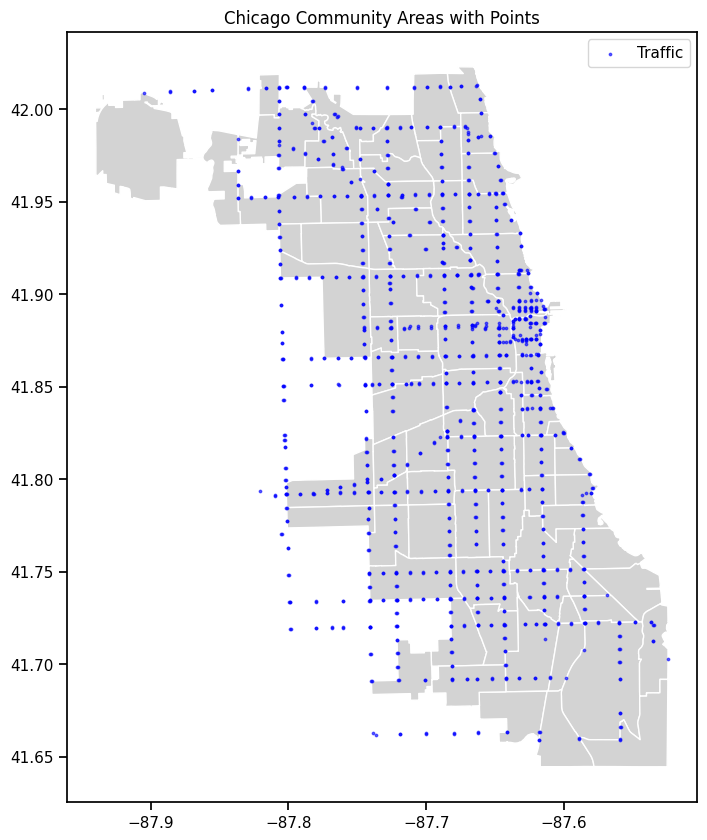

In [26]:
fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(column='community', ax=ax, color='lightgray',    # light neutral background
    edgecolor='white', legend=False,
             legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

gdf_points1.plot(ax=ax, color='blue', markersize=3, alpha=0.6, label='Traffic')

plt.legend()
plt.title('Chicago Community Areas with Points')

In [27]:
# using geopandas 'within' function!
inside = gdf_points1.within(chicago.unary_union)
outside_count = (~inside).sum()

print(f"Points outside Chicago boundaries: {outside_count}")

Points outside Chicago boundaries: 159


Great, it seems the values here that are missing a neighborhood are the ones outside of the neighborhood limit. I'll remove them, since I am going to analyze based on chicago neighborhood.

In [28]:
traffic = traffic.dropna(subset=['community'])
traffic.isnull().sum()
#that cleans it up

SEGMENTID             0
STREET                0
DIRECTION             0
FROM_STREET           0
TO_STREET             0
LENGTH                0
 STREET_HEADING       0
 COMMENTS          1007
START_LONGITUDE       0
 START_LATITUDE       0
END_LONGITUDE         0
 END_LATITUDE         0
 CURRENT_SPEED        0
 LAST_UPDATED         0
geometry              0
index_right           0
area_numbe            0
community             0
area_num_1            0
shape_area            0
shape_len             0
dtype: int64

### Preparing/Cleaning Bus Stops and L Stops

In [29]:
#splitting bus stops and L stops into two coords (right now they have columns like "coordinates" and I need two)
    #bus stops
bus_stops["coords_clean"] = (
    bus_stops["the_geom"]
    .str.replace("POINT (", "", regex=False)
    .str.replace(")", "", regex=False)
)
bus_stops[["LON", "LAT"]] = bus_stops["coords_clean"].str.split(" ", expand=True)
bus_stops["LON"] = bus_stops["LON"].astype(float)
bus_stops["LAT"] = bus_stops["LAT"].astype(float)

gdf_points2 = gpd.GeoDataFrame(bus_stops, geometry = gpd.points_from_xy(bus_stops['LON'], bus_stops['LAT']), crs = "EPSG:4326")
bus_stops = gpd.sjoin(gdf_points2, chicago, how="left", predicate="within")


In [30]:
    #L stops
L_stops["coords_clean"] = (
    L_stops["Location"]
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)
L_stops[["LAT", "LON"]] = L_stops["coords_clean"].str.split(",", expand=True)
L_stops["LON"] = L_stops["LON"].astype(float)
L_stops["LAT"] = L_stops["LAT"].astype(float)

gdf_points3 = gpd.GeoDataFrame(L_stops, geometry = gpd.points_from_xy(L_stops['LON'], L_stops['LAT']), crs = "EPSG:4326")
L_stops = gpd.sjoin(gdf_points3, chicago, how="left", predicate="within")
L_stops.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,...,coords_clean,LAT,LON,geometry,index_right,area_numbe,community,area_num_1,shape_area,shape_len
0,30162,W,18th (54th/Cermak-bound),18th,18th (Pink Line),40830,True,False,False,False,...,"41.857908, -87.669147",41.857908,-87.669147,POINT (-87.66915 41.85791),30.0,31.0,LOWER WEST SIDE,31,8.155072e+07,43229.372704
1,30161,E,18th (Loop-bound),18th,18th (Pink Line),40830,True,False,False,False,...,"41.857908, -87.669147",41.857908,-87.669147,POINT (-87.66915 41.85791),30.0,31.0,LOWER WEST SIDE,31,8.155072e+07,43229.372704
2,30022,N,35th/Archer (Loop-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,...,"41.829353, -87.680622",41.829353,-87.680622,POINT (-87.68062 41.82935),58.0,59.0,MCKINLEY PARK,59,3.943180e+07,26014.096837
3,30023,S,35th/Archer (Midway-bound),35th/Archer,35th/Archer (Orange Line),40120,True,False,False,False,...,"41.829353, -87.680622",41.829353,-87.680622,POINT (-87.68062 41.82935),58.0,59.0,MCKINLEY PARK,59,3.943180e+07,26014.096837
4,30213,N,35-Bronzeville-IIT (Harlem-bound),35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),41120,True,False,False,True,...,"41.831677, -87.625826",41.831677,-87.625826,POINT (-87.62583 41.83168),34.0,35.0,DOUGLAS,35,4.600462e+07,31027.054510


## EDA: Visualizing the placement of variables by neighborhood

(I went back to this graph a lot during my analysis, commenting out the irrelevant data so it's not too crowded. I know it's tough to read now, it was more for reference for me.)

Text(0.5, 1.0, 'Chicago Community Areas with Points')

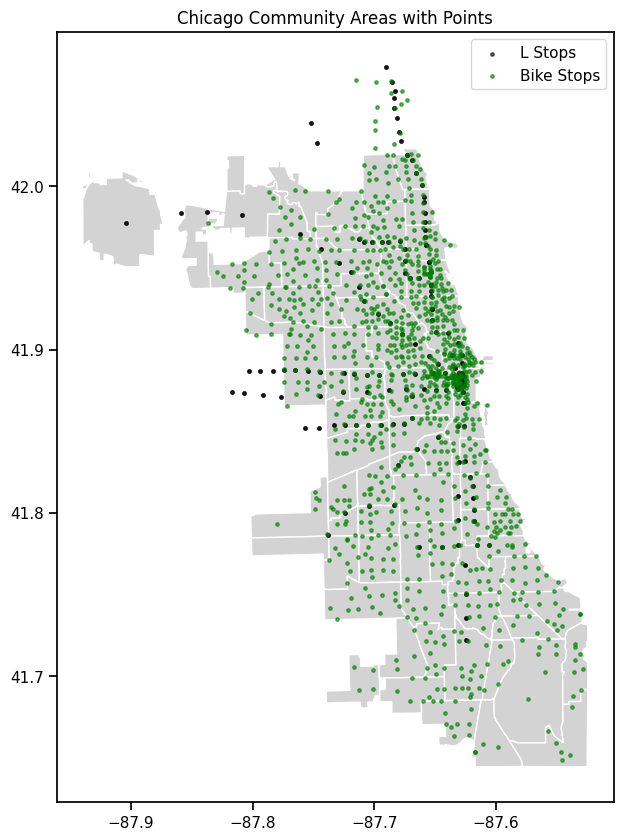

In [31]:
fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(column='community', ax=ax, color='lightgray',    # light neutral background
    edgecolor='white', legend=False,
             legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

#gdf_points2.plot(ax=ax, color='yellow', markersize=3, alpha=0.6, label='Bus Stops')
#gdf_points1.plot(ax=ax, color='blue', markersize=3, alpha=0.6, label='Traffic')
gdf_points3.plot(ax=ax, color='black', markersize=6, alpha=0.6, label='L Stops')
gdf_points4.plot(ax=ax, color='green', markersize=6, alpha=0.6, label='Bike Stops')


#gdf_points.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='divvy_ride_start') this shows the divvy points and takes about 1 million years to load

plt.legend()
plt.title('Chicago Community Areas with Points')


## Cleaning/Prepping Traffic and Population

In [32]:
#for traffic: A value of -1 means no estimate is available, according to the documentation, so I'll clean them up and get rid of them
traffic_cleaned = traffic[traffic[' CURRENT_SPEED'] != -1]

traffic_cleaned_neighb = traffic_cleaned.groupby(['community'])[' CURRENT_SPEED'].agg(['mean'])
traffic_cleaned_neighb.reset_index(inplace=True)
traffic_cleaned_neighb = traffic_cleaned_neighb.rename(columns={'mean':'avg_traffic_speed'})

traffic_cleaned_neighb #this I will append to whatever finished product I have

,community,avg_traffic_speed
0,ALBANY PARK,22.333333
1,ARCHER HEIGHTS,23.555556
2,ARMOUR SQUARE,23.750000
3,ASHBURN,25.304348
4,AUBURN GRESHAM,23.107143
...,...,...
69,WEST LAWN,24.888889
70,WEST PULLMAN,32.333333
71,WEST RIDGE,22.285714
72,WEST TOWN,21.421053


<Axes: ylabel='Frequency'>

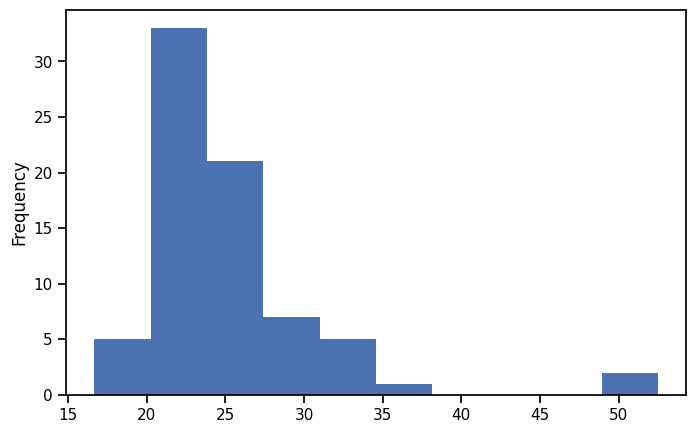

In [33]:
traffic_cleaned_neighb.avg_traffic_speed.plot.hist()

In [34]:
#cleaning population (removing 2023) - I'm removing 2023 since my divvy data is 2024-2025 only
population['ACS Year'] = pd.to_datetime(population['ACS Year'], errors='coerce')
population = population[population['ACS Year'].dt.year != 2023]

#finding avg pop per neighborhood (dince divvy data is 2024-2025, I'll average populations)
population_avg = population.groupby(['Community Area'])['Total Population'].agg(['mean'])
population_avg.reset_index(inplace=True)
population_avg = population_avg.rename(columns={'Community Area': 'community', 'mean':'population_avg'})
population_avg #yay! this is good for my per capita table!


,community,population_avg
0,ALBANY PARK,47830.0
1,ARCHER HEIGHTS,13875.0
2,ARMOUR SQUARE,13149.0
3,ASHBURN,42842.0
4,AUBURN GRESHAM,46483.0
...,...,...
72,WEST LAWN,32451.0
73,WEST PULLMAN,25159.0
74,WEST RIDGE,79220.0
75,WEST TOWN,86453.0


## Final Prep of Each Dataframe before Joining

Okay, at this point, I could make a table with population, mean traffic. I need to organize # of L stops, # of divvy stops, # of bus stops. Finally then I will add the divvy data and deal with the messes there. 

In [35]:
num_L_stops = (L_stops.groupby('community')['MAP_ID'].nunique().reset_index().rename(columns={'MAP_ID': 'num_L_stops'}))

num_bus_stops = (bus_stops.groupby('community')['SYSTEMSTOP'].nunique().reset_index().rename(columns={'SYSTEMSTOP': 'num_bus_stops'}))

num_bike_stops = (bike_stations.groupby('community')['ID'].nunique().reset_index().rename(columns={'ID': 'num_bike_stops'}))

num_L_stops.head()

,community,num_L_stops
0,ALBANY PARK,3
1,ARMOUR SQUARE,2
2,AUSTIN,5
3,AVONDALE,1
4,BRIDGEPORT,1


In [36]:
num_bike_stops.head()

,community,num_bike_stops
0,ALBANY PARK,8
1,ARCHER HEIGHTS,9
2,ARMOUR SQUARE,9
3,ASHBURN,13
4,AUBURN GRESHAM,11


In [37]:
num_L_stops.head()

,community,num_L_stops
0,ALBANY PARK,3
1,ARMOUR SQUARE,2
2,AUSTIN,5
3,AVONDALE,1
4,BRIDGEPORT,1


In [38]:
divvy_nb_count = (divvy_nb.groupby('community')['ride_id'].nunique().reset_index().rename(columns={'ride_id': 'num_divvy_rides'}))
divvy_nb_count.head()

,community,num_divvy_rides
0,ALBANY PARK,25540
1,ARCHER HEIGHTS,3470
2,ARMOUR SQUARE,65029
3,ASHBURN,2263
4,AUBURN GRESHAM,3112


Okay! I think everything is ready to concatenate my first comparison dataset!

## Making the dataset

In [39]:
merged = population_avg \
    .merge(num_L_stops, on='community', how='left') \
    .merge(num_bus_stops, on='community', how='left') \
    .merge(num_bike_stops, on='community', how='left') \
    .merge(divvy_nb_count, on='community', how = 'left') \
    .merge(traffic_cleaned_neighb, on='community', how='left') 

merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333
1,ARCHER HEIGHTS,13875.0,NaN,66,9.0,3470,23.555556
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000
3,ASHBURN,42842.0,NaN,131,13.0,2263,25.304348
4,AUBURN GRESHAM,46483.0,NaN,172,11.0,3112,23.107143
...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,NaN,79,10.0,2556,24.888889
73,WEST PULLMAN,25159.0,NaN,104,11.0,1153,32.333333
74,WEST RIDGE,79220.0,NaN,195,21.0,35596,22.285714
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053


In [40]:
#this is the per capita ones

merged['L_stops_per_capita'] = merged['num_L_stops'] / merged['population_avg']
merged['bus_stops_per_capita'] = merged['num_bus_stops'] / merged['population_avg']
merged['bike_stops_per_capita'] = merged['num_bike_stops'] / merged['population_avg']
merged['divvy_per_capita'] = merged['num_divvy_rides'] / merged['population_avg']

merged


,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974
1,ARCHER HEIGHTS,13875.0,NaN,66,9.0,3470,23.555556,NaN,0.004757,0.000649,0.250090
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547
3,ASHBURN,42842.0,NaN,131,13.0,2263,25.304348,NaN,0.003058,0.000303,0.052822
4,AUBURN GRESHAM,46483.0,NaN,172,11.0,3112,23.107143,NaN,0.003700,0.000237,0.066949
...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,NaN,79,10.0,2556,24.888889,NaN,0.002434,0.000308,0.078765
73,WEST PULLMAN,25159.0,NaN,104,11.0,1153,32.333333,NaN,0.004134,0.000437,0.045829
74,WEST RIDGE,79220.0,NaN,195,21.0,35596,22.285714,NaN,0.002461,0.000265,0.449331
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143


## Adding a population density metric

In [41]:
chicago_proj = chicago.to_crs(epsg=3435)  # Illinois State Plane (meters)

chicago_proj['area_sqm'] = chicago_proj.geometry.area

chicago_proj['area_km2'] = chicago_proj['area_sqm'] / 1e6 #convert to km

neighborhood_areas = chicago_proj[['community', 'area_km2']]
print(neighborhood_areas)

             community    area_km2
0          ROGERS PARK   51.259902
1           WEST RIDGE   98.429095
2               UPTOWN   65.095643
3       LINCOLN SQUARE   71.352328
4         NORTH CENTER   57.054168
..                 ...         ...
72  WASHINGTON HEIGHTS   79.635753
73     MOUNT GREENWOOD   75.584290
74         MORGAN PARK   91.877341
75               OHARE  371.835608
76           EDGEWATER   48.449991

[77 rows x 2 columns]


In [42]:
merged = merged \
    .merge(neighborhood_areas, on='community', how='left')

merged['pop_density'] = merged['population_avg']/merged['area_km2']
merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545
1,ARCHER HEIGHTS,13875.0,NaN,66,9.0,3470,23.555556,NaN,0.004757,0.000649,0.250090,55.922506,248.111200
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447
3,ASHBURN,42842.0,NaN,131,13.0,2263,25.304348,NaN,0.003058,0.000303,0.052822,135.460337,316.269699
4,AUBURN GRESHAM,46483.0,NaN,172,11.0,3112,23.107143,NaN,0.003700,0.000237,0.066949,105.065354,442.419869
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,NaN,79,10.0,2556,24.888889,NaN,0.002434,0.000308,0.078765,82.315302,394.228040
73,WEST PULLMAN,25159.0,NaN,104,11.0,1153,32.333333,NaN,0.004134,0.000437,0.045829,99.365198,253.197301
74,WEST RIDGE,79220.0,NaN,195,21.0,35596,22.285714,NaN,0.002461,0.000265,0.449331,98.429095,804.843325
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143,127.562905,677.728375


## Cleaning the Merged Dataset

In [43]:
merged.isnull().sum()

community                 0
population_avg            0
num_L_stops              35
num_bus_stops             0
num_bike_stops            3
num_divvy_rides           0
avg_traffic_speed         3
L_stops_per_capita       35
bus_stops_per_capita      0
bike_stops_per_capita     3
divvy_per_capita          0
area_km2                  0
pop_density               0
dtype: int64

surprisingly very few null values here.... i know the row would be n/an if there's a zero for the rows where I applied the value_counts funtion (since that's how value_counts deal with 0s), which is L_stops and bike_stops. Let's double check that. 

Text(0.5, 1.0, 'Chicago Community Areas with Points')

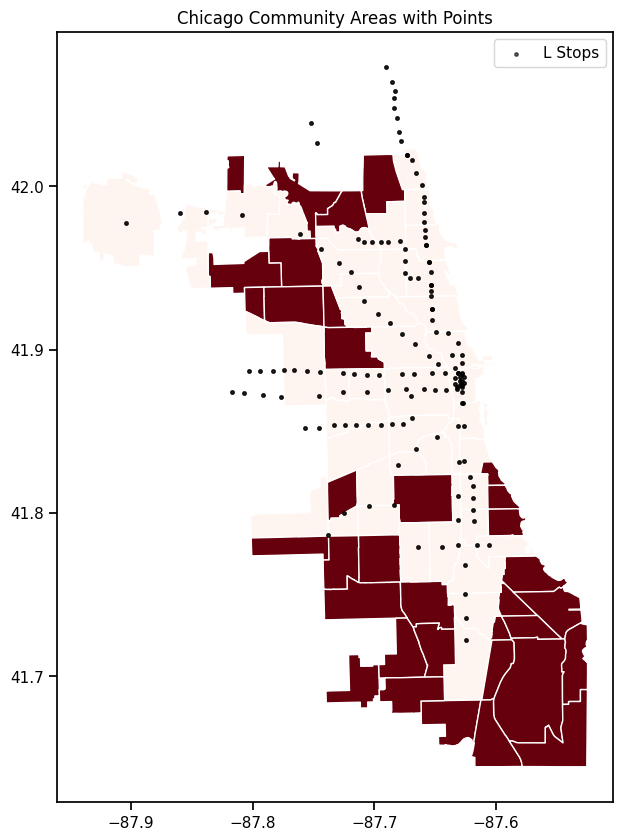

In [44]:
#printing the neighborhoods with null L stops
no_L = merged.loc[merged['num_L_stops'].isna(), 'community'].unique()


#trying to see graphically - this should highlight red the null communities and also print the L stops, so I can see if there is overlap (if i'm right there should be none)
fig, ax = plt.subplots(figsize=(15, 10))

chicago['highlight'] = chicago['community'].isin(no_L)

chicago.plot(column='highlight', ax=ax, cmap='Reds', edgecolor='white', legend=False)

gdf_points3.plot(ax=ax, color='black', markersize=6, alpha=0.6, label='L Stops')

plt.legend()
plt.title('Chicago Community Areas with Points')


Yay! looks like for L stops, a null value means zero. Let's check bike stops. 

Text(0.5, 1.0, 'Chicago Community Areas with Points')

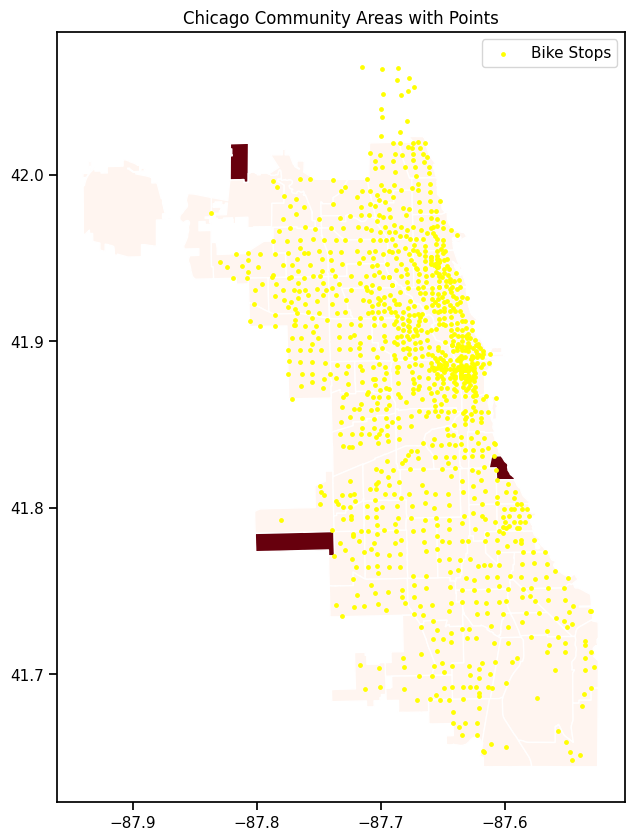

In [45]:
#printing the neighborhoods with null L stops
no_bike = merged.loc[merged['num_bike_stops'].isna(), 'community'].unique()


#trying to see graphically (same code)
fig, ax = plt.subplots(figsize=(15, 10))

chicago['highlight2'] = chicago['community'].isin(no_bike)

chicago.plot(column='highlight2', ax=ax, cmap='Reds', edgecolor='white', legend=False)

gdf_points4.plot(ax=ax, color='yellow', markersize=6, alpha=1, label='Bike Stops') #trying yellow since it'll show up well on the dark red maybe?

plt.legend()
plt.title('Chicago Community Areas with Points')


Looks like the same for bike stops. N/A means zero. Let's impute those.

In [46]:
cols_to_impute = ['num_L_stops', 'num_bike_stops', 'L_stops_per_capita', 'bike_stops_per_capita']
merged[cols_to_impute] = merged[cols_to_impute].fillna(0)
merged.isna().sum()

community                0
population_avg           0
num_L_stops              0
num_bus_stops            0
num_bike_stops           0
num_divvy_rides          0
avg_traffic_speed        3
L_stops_per_capita       0
bus_stops_per_capita     0
bike_stops_per_capita    0
divvy_per_capita         0
area_km2                 0
pop_density              0
dtype: int64

Now let's look into the null traffic speed. 

In [47]:
merged[merged.isna().any(axis=1)]


,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density
19,EAST GARFIELD PARK,19855.0,4.0,136,14.0,9877,NaN,0.000201,0.006850,0.000705,0.497457,53.883221,368.482056
30,HEGEWISCH,8895.0,0.0,47,6.0,1093,NaN,0.000000,0.005284,0.000675,0.122878,145.965741,60.938957
62,SOUTH CHICAGO,29072.0,0.0,117,10.0,3859,NaN,0.000000,0.004024,0.000344,0.132739,93.272185,311.689921


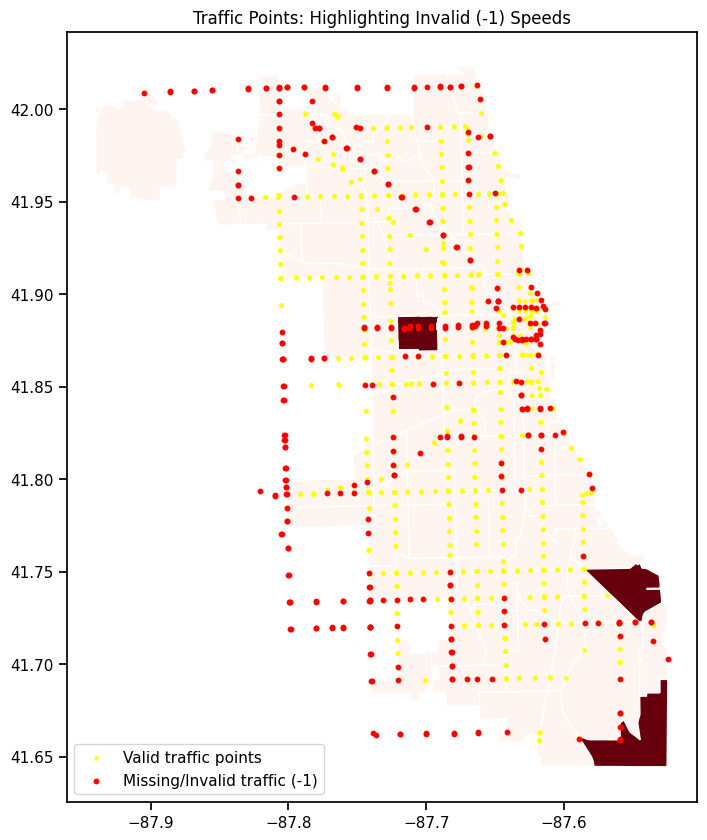

In [48]:
#printing the neighborhoods with null traffic
gdf_points_bad = gdf_points1[gdf_points1[' CURRENT_SPEED'] == -1]
gdf_points_good = gdf_points1[gdf_points1[' CURRENT_SPEED'] != -1]

null_traff = merged.loc[merged['avg_traffic_speed'].isna(), 'community'].unique() #mask for the neighborhoods

#same code as above
fig, ax = plt.subplots(figsize=(15, 10))

chicago['highlight3'] = chicago['community'].isin(null_traff)


chicago.plot(column='highlight3', ax=ax, cmap='Reds', edgecolor='white', legend=False)

gdf_points_good.plot(ax=ax, color='yellow', markersize=6, alpha=0.8, label='Valid traffic points') #if there is a yellow in my red blocks, something's wrong. it should be all red if my hunch is right and all the data there is -1

gdf_points_bad.plot(ax=ax, color='red', markersize=10, alpha=1, label='Missing/Invalid traffic (-1)')

plt.legend()
plt.title('Traffic Points: Highlighting Invalid (-1) Speeds');


Okay, since there is no yellow in the red polygons, that means the estimated traffic speed in those areas was -1, meaning no estimate was available, and I dropped the value. I don't want to remove the community, so I'll just remember those are null for that reason.

## Data Prep
- I've already done some prep, like some standardziation (per capita measurements)
- I think, since I have so many categories (communities) it would benefit me to bin them (for histogram data, etc)

https://en.wikipedia.org/wiki/Community_areas_in_Chicago

https://research.dom.edu/governmentdata/chicago 

- These links say that there are established 9 regions (sort of just divided into sides). I'll bin them in this way. I think maybe the cleanest way to do it is to sum the non-per-capita data, and recalculate per capita stuff. 

In [49]:
#making a dictionary to divide into "sides" (I uploaded an image to gemini and had it make the dictionary since it would just be tedious.)

chicago_sides = {
    # FAR NORTH SIDE
    'ROGERS PARK': 'FAR NORTH SIDE',
    'WEST RIDGE': 'FAR NORTH SIDE',
    'UPTOWN': 'FAR NORTH SIDE',
    'LINCOLN SQUARE': 'FAR NORTH SIDE',
    'EDISON PARK': 'FAR NORTH SIDE',
    'NORWOOD PARK': 'FAR NORTH SIDE',
    'JEFFERSON PARK': 'FAR NORTH SIDE',
    'FOREST GLEN': 'FAR NORTH SIDE',
    'NORTH PARK': 'FAR NORTH SIDE',
    'ALBANY PARK': 'FAR NORTH SIDE',
    'EDGEWATER': 'FAR NORTH SIDE',
    "OHARE": 'FAR NORTH SIDE',  # CA 76

    # NORTH SIDE
    'NORTH CENTER': 'NORTH SIDE',
    'LAKE VIEW': 'NORTH SIDE',
    'LINCOLN PARK': 'NORTH SIDE',
    'AVONDALE': 'NORTH SIDE',
    'LOGAN SQUARE': 'NORTH SIDE',

    # NORTH WEST SIDE (Note: Image title is "North West Side", not "Northwest Side")
    'PORTAGE PARK': 'NORTH WEST SIDE',
    'IRVING PARK': 'NORTH WEST SIDE',
    'DUNNING': 'NORTH WEST SIDE',
    'MONTCLARE': 'NORTH WEST SIDE',
    'BELMONT CRAGIN': 'NORTH WEST SIDE',
    'HERMOSA': 'NORTH WEST SIDE',

    # WEST SIDE
    'HUMBOLDT PARK': 'WEST SIDE',
    'WEST TOWN': 'WEST SIDE',
    'AUSTIN': 'WEST SIDE',
    'WEST GARFIELD PARK': 'WEST SIDE',
    'EAST GARFIELD PARK': 'WEST SIDE',
    'NEAR WEST SIDE': 'WEST SIDE',
    'NORTH LAWNDALE': 'WEST SIDE',
    'SOUTH LAWNDALE': 'WEST SIDE',
    'LOWER WEST SIDE': 'WEST SIDE',

    # CENTRAL
    'NEAR NORTH SIDE': 'CENTRAL',
    'LOOP': 'CENTRAL',
    'NEAR SOUTH SIDE': 'CENTRAL',

    # SOUTH SIDE
    'ARMOUR SQUARE': 'SOUTH SIDE',
    'DOUGLAS': 'SOUTH SIDE',
    'OAKLAND': 'SOUTH SIDE',
    'FULLER PARK': 'SOUTH SIDE',
    'GRAND BOULEVARD': 'SOUTH SIDE',
    'KENWOOD': 'SOUTH SIDE',
    'WASHINGTON PARK': 'SOUTH SIDE',
    'HYDE PARK': 'SOUTH SIDE',
    'WOODLAWN': 'SOUTH SIDE',
    'SOUTH SHORE': 'SOUTH SIDE',
    'BRIDGEPORT': 'SOUTH SIDE', # Grouped here in the image's structure
    'GREATER GRAND CROSSING': 'SOUTH SIDE',

    # SOUTHWEST SIDE
    'GARFIELD RIDGE': 'SOUTHWEST SIDE',
    'ARCHER HEIGHTS': 'SOUTHWEST SIDE',
    'BRIGHTON PARK': 'SOUTHWEST SIDE',
    'MCKINLEY PARK': 'SOUTHWEST SIDE',
    'NEW CITY': 'SOUTHWEST SIDE',
    'WEST ELSDON': 'SOUTHWEST SIDE',
    'GAGE PARK': 'SOUTHWEST SIDE',
    'CLEARING': 'SOUTHWEST SIDE',
    'WEST LAWN': 'SOUTHWEST SIDE',
    'CHICAGO LAWN': 'SOUTHWEST SIDE',
    'WEST ENGLEWOOD': 'SOUTHWEST SIDE',
    'ENGLEWOOD': 'SOUTHWEST SIDE',

    # FAR SOUTHWEST SIDE
    'ASHBURN': 'FAR SOUTHWEST SIDE',
    'AUBURN GRESHAM': 'FAR SOUTHWEST SIDE',
    'BEVERLY': 'FAR SOUTHWEST SIDE',
    'WASHINGTON HEIGHTS': 'FAR SOUTHWEST SIDE',
    'MOUNT GREENWOOD': 'FAR SOUTHWEST SIDE',
    'MORGAN PARK': 'FAR SOUTHWEST SIDE',

    # FAR SOUTHEAST SIDE
    'CHATHAM': 'FAR SOUTHEAST SIDE',
    'AVALON PARK': 'FAR SOUTHEAST SIDE',
    'SOUTH CHICAGO': 'FAR SOUTHEAST SIDE',
    'BURNSIDE': 'FAR SOUTHEAST SIDE',
    'CALUMET HEIGHTS': 'FAR SOUTHEAST SIDE',
    'ROSELAND': 'FAR SOUTHEAST SIDE',
    'PULLMAN': 'FAR SOUTHEAST SIDE',
    'SOUTH DEERING': 'FAR SOUTHEAST SIDE',
    'EAST SIDE': 'FAR SOUTHEAST SIDE',
    'WEST PULLMAN': 'FAR SOUTHEAST SIDE',
    'RIVERDALE': 'FAR SOUTHEAST SIDE',
    'HEGEWISCH': 'FAR SOUTHEAST SIDE',
}

In [50]:
merged['side'] = merged['community'].map(chicago_sides)

merged.head()

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545,FAR NORTH SIDE
1,ARCHER HEIGHTS,13875.0,0.0,66,9.0,3470,23.555556,0.000000,0.004757,0.000649,0.250090,55.922506,248.111200,SOUTHWEST SIDE
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE
3,ASHBURN,42842.0,0.0,131,13.0,2263,25.304348,0.000000,0.003058,0.000303,0.052822,135.460337,316.269699,FAR SOUTHWEST SIDE
4,AUBURN GRESHAM,46483.0,0.0,172,11.0,3112,23.107143,0.000000,0.003700,0.000237,0.066949,105.065354,442.419869,FAR SOUTHWEST SIDE


I want to visualize them to make sure I'm not missing any neighborhoods

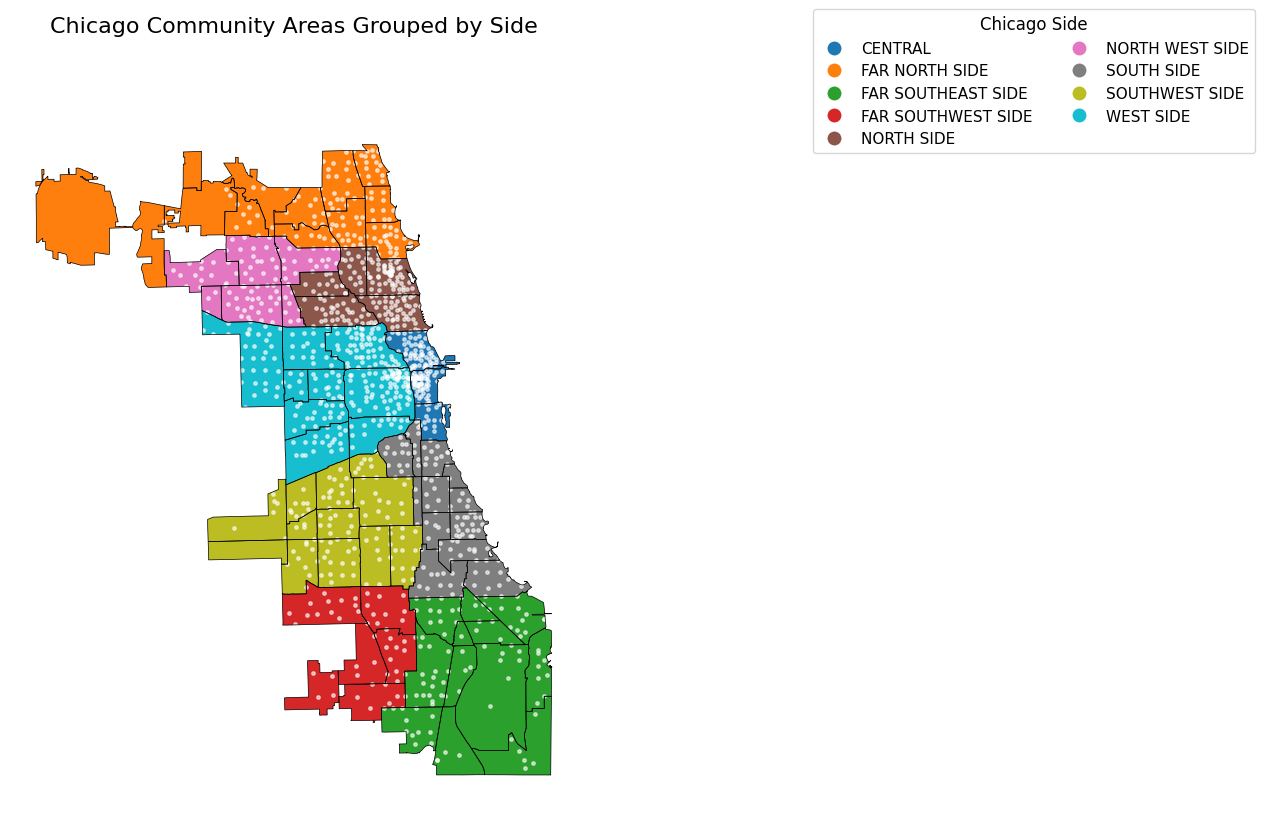

In [51]:
chicago['side'] = chicago['community'].map(chicago_sides) #mapping sides to the communties so I can graph to see the sections

fig, ax = plt.subplots(figsize=(15, 10))

chicago.plot(
    column='side', 
    ax=ax, 
    legend=True, 
    cmap='tab10',  # Using a good categorical colormap
    legend_kwds={'ncol': 2, 'bbox_to_anchor': (1.4, 1.05), 'title': 'Chicago Side'}
)

gdf_points4.plot(ax=ax, color='white', markersize=6, alpha=0.6, label='Bike Stops')

chicago.boundary.plot(ax=ax, linewidth=0.5, color='black')
ax.set_axis_off()

plt.title('Chicago Community Areas Grouped by Side', fontsize=16)
plt.show()

In [52]:
#Initially we were missing ohare and the loop so I added those. (Loop was called "the Loop" in dictonary and ohare was called "O'hare"). It looks good after fixing that. 

### Making a binned dataset

Now that I have added the "sides" bins, I need to make a new dataframe with the combined information. 

In [53]:
side_data = merged.groupby('side').agg(
    #sums for not per-capita-data (CAREFUL TO GET SAME ORDER FOR CORRELATION MATRIX GRAPH LATER)

    Total_Population=('population_avg', 'sum'),
    Total_L_Stops=('num_L_stops', 'sum'),
    Total_Bus_Stops=('num_bus_stops', 'sum'),
    Total_Divvy_Stations=('num_bike_stops', 'sum'),
    Total_Divvy_Rides=('num_divvy_rides', 'sum')
)
side_data.head()


,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides
side,,,,,
CENTRAL,156226.0,25.0,493,134.0,3734447
FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282
FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394
FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637
NORTH SIDE,296205.0,15.0,844,178.0,2968640


In [54]:
# I need the original traffic dataset (with community) to get good averages. If I average
# based on merged, then each neighborhood has equal weight, and I think it will be more accurate if I go from the start.

traffic['side'] = traffic['community'].map(chicago_sides) #adding "side"
traffic_cleaned2 = traffic[traffic[' CURRENT_SPEED'] != -1] #getting rid of -1s (no data)

#same process as I did above to get the avg by community.
traffic_cleaned_side = traffic_cleaned2.groupby(['side'])[' CURRENT_SPEED'].agg(['mean'])
traffic_cleaned_side.reset_index(inplace=True)
traffic_cleaned_side = traffic_cleaned_side.rename(columns={'mean':'avg_traffic_speed_side'})

traffic_cleaned_side.head()
#okay this looks good. I'll join with the one above^

,side,avg_traffic_speed_side
0,CENTRAL,22.500000
1,FAR NORTH SIDE,24.725000
2,FAR SOUTHEAST SIDE,26.623188
3,FAR SOUTHWEST SIDE,24.487500
4,NORTH SIDE,23.917808


In [55]:
side_data = side_data \
    .merge(traffic_cleaned_side, on=['side'], how='left')

side_data

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808
5,NORTH WEST SIDE,271227.0,3.0,898,89.0,119101,22.896552
6,SOUTH SIDE,246744.0,14.0,1295,114.0,709917,27.386667
7,SOUTHWEST SIDE,358308.0,8.0,1472,111.0,48670,24.884058
8,WEST SIDE,477402.0,34.0,1983,250.0,2244765,22.100000


In [56]:
#Now I need the per capita. I'll reuse my code.
side_data['L_stops_per_capita'] = side_data['Total_L_Stops'] / side_data['Total_Population']
side_data['bus_stops_per_capita'] = side_data['Total_Bus_Stops'] / side_data['Total_Population']
side_data['bike_stops_per_capita'] = side_data['Total_Divvy_Stations'] / side_data['Total_Population']
side_data['divvy_per_capita'] = side_data['Total_Divvy_Rides'] / side_data['Total_Population']

side_data

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000,0.000160,0.003156,0.000858,23.904132
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000,0.000048,0.002720,0.000261,1.924694
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188,0.000014,0.004997,0.000439,0.097418
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500,0.000000,0.003731,0.000284,0.071866
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808,0.000051,0.002849,0.000601,10.022248
5,NORTH WEST SIDE,271227.0,3.0,898,89.0,119101,22.896552,0.000011,0.003311,0.000328,0.439119
6,SOUTH SIDE,246744.0,14.0,1295,114.0,709917,27.386667,0.000057,0.005248,0.000462,2.877140
7,SOUTHWEST SIDE,358308.0,8.0,1472,111.0,48670,24.884058,0.000022,0.004108,0.000310,0.135833
8,WEST SIDE,477402.0,34.0,1983,250.0,2244765,22.100000,0.000071,0.004154,0.000524,4.702044


In [57]:
side_data.isnull().sum()

side                      0
Total_Population          0
Total_L_Stops             0
Total_Bus_Stops           0
Total_Divvy_Stations      0
Total_Divvy_Rides         0
avg_traffic_speed_side    0
L_stops_per_capita        0
bus_stops_per_capita      0
bike_stops_per_capita     0
divvy_per_capita          0
dtype: int64

Great, this is my binned dataset.

# Exploratory data analysis

## 1: Correlation Matrix Overall (unbinned, both per cap and not per cap)
I'm using unbinned since having 77 rows gives more robust correlation estimates than only 9.

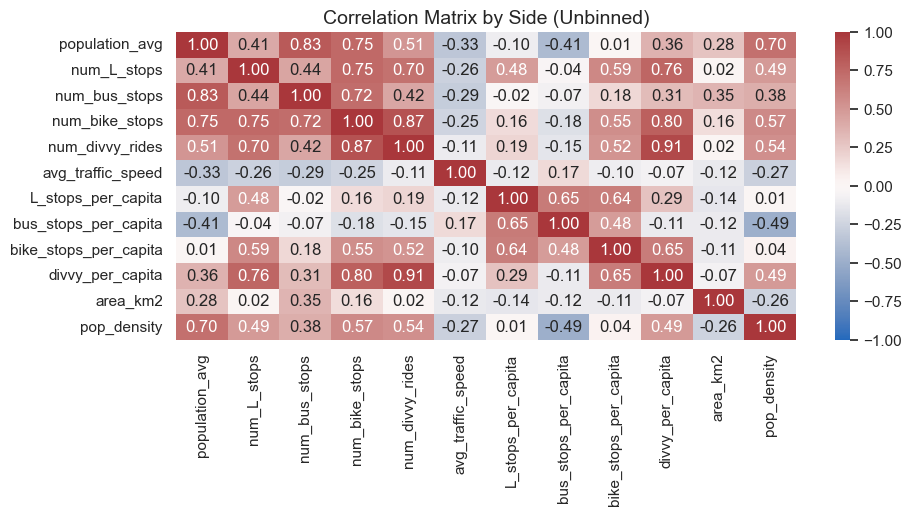

In [226]:
fig, (ax1) = plt.subplots(1, figsize=(10, 4))

sns.heatmap(merged.select_dtypes(include='number').corr(), cmap='vlag', annot=True, fmt=".2f", ax=ax1, vmin = -1, vmax=1) #picked vlag since that emphazises strong negative and positive corr
ax1.set_title('Correlation Matrix by Side (Unbinned)', fontsize=14);

### Interesting / Unexpected Things
1) Traffic speed is almost unrelated to the transit infrastructure per capita and to divvy bike rides. This seems probably inaccurate (meaning unfortunately I may just not have enough traffic intel).
2) Population density is related to divvy rides (0.49) but not to bike stops (0.04)


<Axes: xlabel='pop_density', ylabel='rides_per_station'>

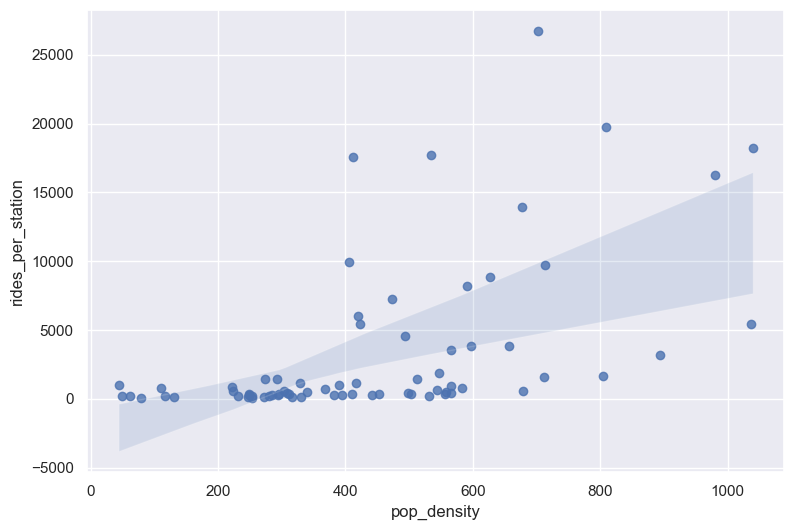

In [283]:
merged['rides_per_station'] = (merged['num_divvy_rides'] / df_no_central['num_bike_stops'])

sns.regplot(data=merged,x='pop_density',y='rides_per_station')

# Infrastructure mismatch -  the higher pop density leads to overused stations

q
q

q

q

q

q

qq
q
q

q
q

q

q

q

q

q

q
q

q
q

q

q

q

q

q
q


q
q

q
q

### Interesting/Unexpected Things to Dive Into:
1) Infrastructure is all strongly correlated (L stops, bike stops, bus stops all have high correlations, both per capita and not). However, number of divvy rides per capita is only correlated with number of divvy stops, not the other infrastructures. Why? Will people pick alternate transit options if they're given them over divvy bikes?
1) Traffic speed is not strongly related to overall population density (~-0.2) or the number of L stops (~-0.1) which defies common sense (we expect more density/transit to mean slower traffic). Why?
2) Population density is related to divvy rides (0.49) but not to bike stops (-0.11)
4) community size not corr with divvy usage (may think suburban but no)
These are the questions I want to dive into.

<Axes: xlabel='area_km2', ylabel='divvy_per_capita'>

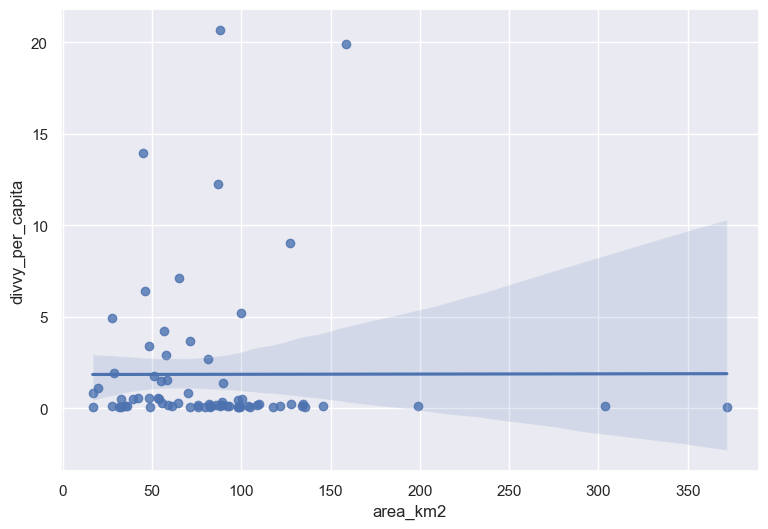

In [227]:
#q4
sns.regplot(data=df_no_central, x='area_km2', y='divvy_per_capita')

<Axes: xlabel='pop_density', ylabel='divvy_per_capita'>

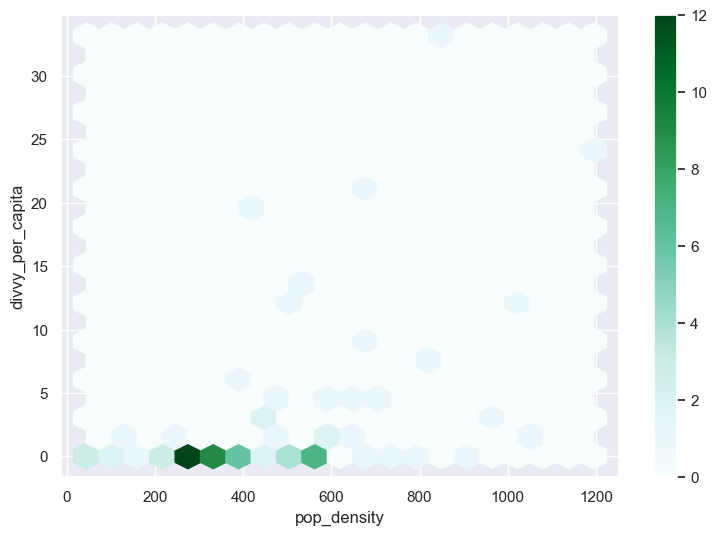

In [228]:
#q3
merged.plot.hexbin(x='pop_density', y='divvy_per_capita', gridsize=20)


<Axes: xlabel='avg_traffic_speed', ylabel='divvy_per_capita'>

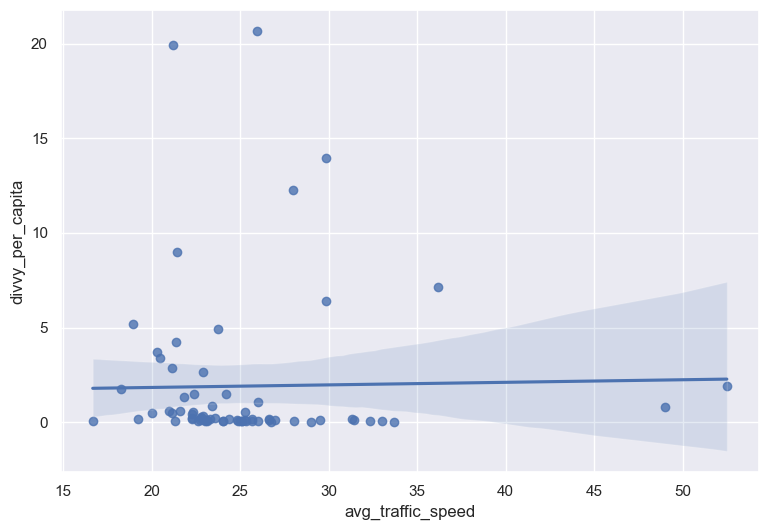

In [229]:
sns.regplot(data=df_no_central, x='avg_traffic_speed', y='divvy_per_capita')


<Axes: xlabel='speed_bin', ylabel='divvy_per_capita'>

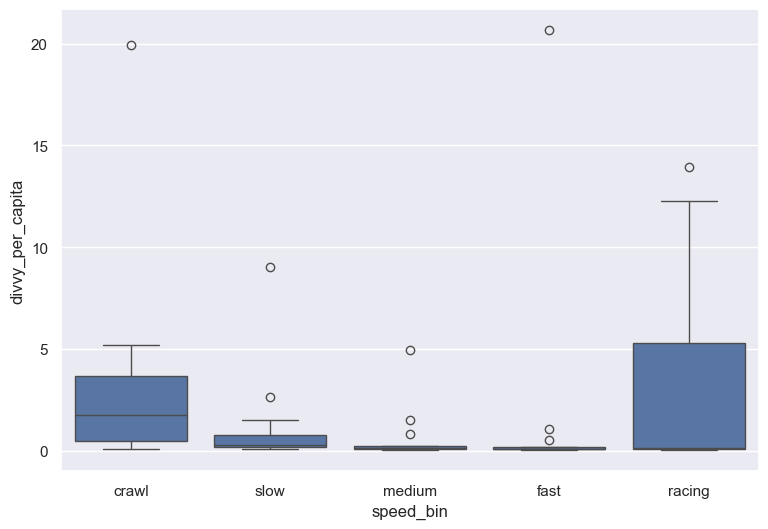

In [230]:
sns.boxplot(data=df_no_central, x='speed_bin', y='divvy_per_capita')

In [231]:
merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side,speed_bin
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545,FAR NORTH SIDE,slow
1,ARCHER HEIGHTS,13875.0,0.0,66,9.0,3470,23.555556,0.000000,0.004757,0.000649,0.250090,55.922506,248.111200,SOUTHWEST SIDE,medium
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE,medium
3,ASHBURN,42842.0,0.0,131,13.0,2263,25.304348,0.000000,0.003058,0.000303,0.052822,135.460337,316.269699,FAR SOUTHWEST SIDE,fast
4,AUBURN GRESHAM,46483.0,0.0,172,11.0,3112,23.107143,0.000000,0.003700,0.000237,0.066949,105.065354,442.419869,FAR SOUTHWEST SIDE,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,0.0,79,10.0,2556,24.888889,0.000000,0.002434,0.000308,0.078765,82.315302,394.228040,SOUTHWEST SIDE,medium
73,WEST PULLMAN,25159.0,0.0,104,11.0,1153,32.333333,0.000000,0.004134,0.000437,0.045829,99.365198,253.197301,FAR SOUTHEAST SIDE,racing
74,WEST RIDGE,79220.0,0.0,195,21.0,35596,22.285714,0.000000,0.002461,0.000265,0.449331,98.429095,804.843325,FAR NORTH SIDE,slow
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143,127.562905,677.728375,WEST SIDE,slow


merged

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

### Question 1: Bus and L Stops versus Divvy Rides

Text(0.5, 1.0, 'Where Infrastructure Exists vs. Where Bikes Are Actually Ridden')

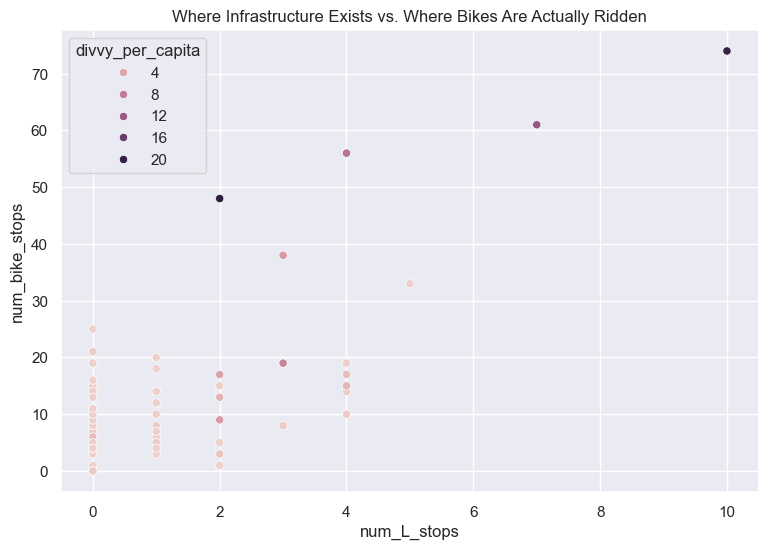

In [232]:
sns.scatterplot(data=df_no_central,
                x='num_L_stops',
                y='num_bike_stops',
                hue='divvy_per_capita')
plt.title("Where Infrastructure Exists vs. Where Bikes Are Actually Ridden")


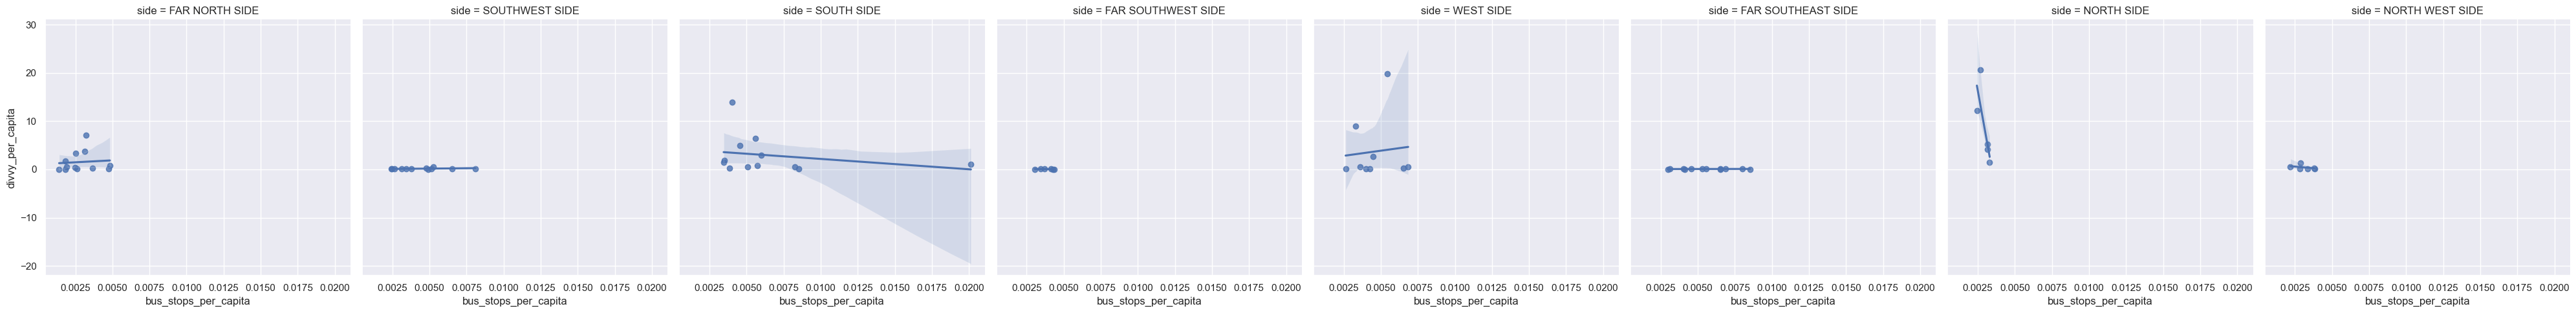

In [233]:
sns.lmplot(data=df_no_central, x='bus_stops_per_capita', y='divvy_per_capita', col='side')


q
q

q

q

q
q


q


q


q


q

q


q

q

q


q


q


q


q


q


q


In [234]:
df_clean = merged.dropna(subset=['avg_traffic_speed'])
df_sorted = df_clean.sort_values(by='avg_traffic_speed', ascending=True)

slowest_5 = df_sorted.head(5)[['community', 'avg_traffic_speed']]
print(slowest_5)

fastest_5 = df_sorted.tail(5)[['community', 'avg_traffic_speed']]
print(fastest_5)

         community  avg_traffic_speed
20       EAST SIDE          16.666667
60     ROGERS PARK          18.250000
40    LOGAN SQUARE          18.944444
64  SOUTH LAWNDALE          19.222222
31         HERMOSA          20.000000
   community  avg_traffic_speed
12  BURNSIDE          33.000000
16  CLEARING          33.666667
66    UPTOWN          36.166667
55   OAKLAND          49.000000
36   KENWOOD          52.500000


    area_numbe           community area_num_1    shape_area     shape_len  \
0          1.0         ROGERS PARK          1  5.125990e+07  34052.397576   
1          2.0          WEST RIDGE          2  9.842909e+07  43020.689458   
2          3.0              UPTOWN          3  6.509564e+07  46972.794555   
3          4.0      LINCOLN SQUARE          4  7.135233e+07  36624.603085   
4          5.0        NORTH CENTER          5  5.705417e+07  31391.669754   
5          6.0           LAKE VIEW          6  8.721480e+07  51973.096868   
6          7.0        LINCOLN PARK          7  8.831640e+07  49478.427771   
7          8.0     NEAR NORTH SIDE          8  7.667590e+07  57293.164952   
8          9.0         EDISON PARK          9  3.163631e+07  25937.226841   
9         10.0        NORWOOD PARK         10  1.219591e+08  80368.374378   
10        11.0      JEFFERSON PARK         11  6.486816e+07  44011.957170   
11        12.0         FOREST GLEN         12  8.913089e+07  74493.821604   

"'\n# Manually set the colors for better visual distinction on the map\nfor category, color in cmap_colors.items():\n    chicago[chicago['speed_category'] == category].plot(\n        ax=ax, \n        color=color if category != 'Other' else cmap_colors['Other'], \n        edgecolor='white',\n        label=category\n    );\n"

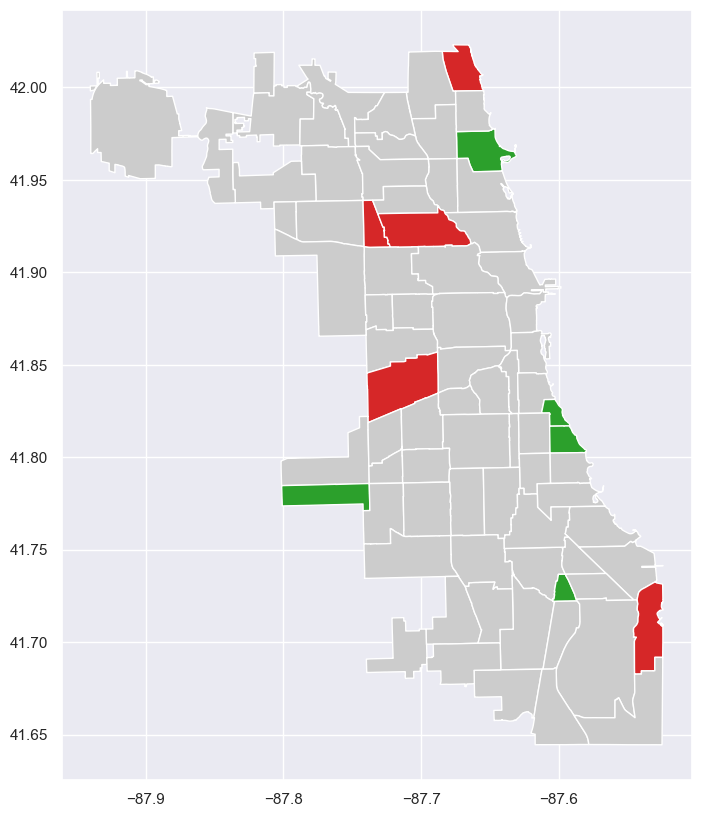

In [235]:
chicago['speed_category'] = 'Other'

slowest_communities = df_sorted.head(5)['community'].tolist()
fastest_communities = df_sorted.tail(5)['community'].tolist()

# Classify the slowest neighborhoods
chicago.loc[chicago['community'].isin(slowest_communities), 'speed_category'] = 'Slowest 5'

# Classify the fastest neighborhoods
chicago.loc[chicago['community'].isin(fastest_communities), 'speed_category'] = 'Fastest 5'
print(chicago.head(60))

fig, ax = plt.subplots(figsize=(15, 10))

# Define colors for the categories
cmap_colors = {
    'Fastest 5': '#2ca02c', # Green
    'Slowest 5': '#d62728', # Red
    'Other': '#cccccc'     # Light Gray
}
color_list = [cmap_colors[category] for category in chicago['speed_category']]

chicago.plot(
    ax=ax, 
    edgecolor='white', 
    color=color_list, # Use the computed color list
    legend=False
);
''''
# Manually set the colors for better visual distinction on the map
for category, color in cmap_colors.items():
    chicago[chicago['speed_category'] == category].plot(
        ax=ax, 
        color=color if category != 'Other' else cmap_colors['Other'], 
        edgecolor='white',
        label=category
    );
'''

## EDA: Correlations by side (per capita data only)
I think it will be beneficial to look at each side, just in case certain neighborhoods are distorting the correlations. 

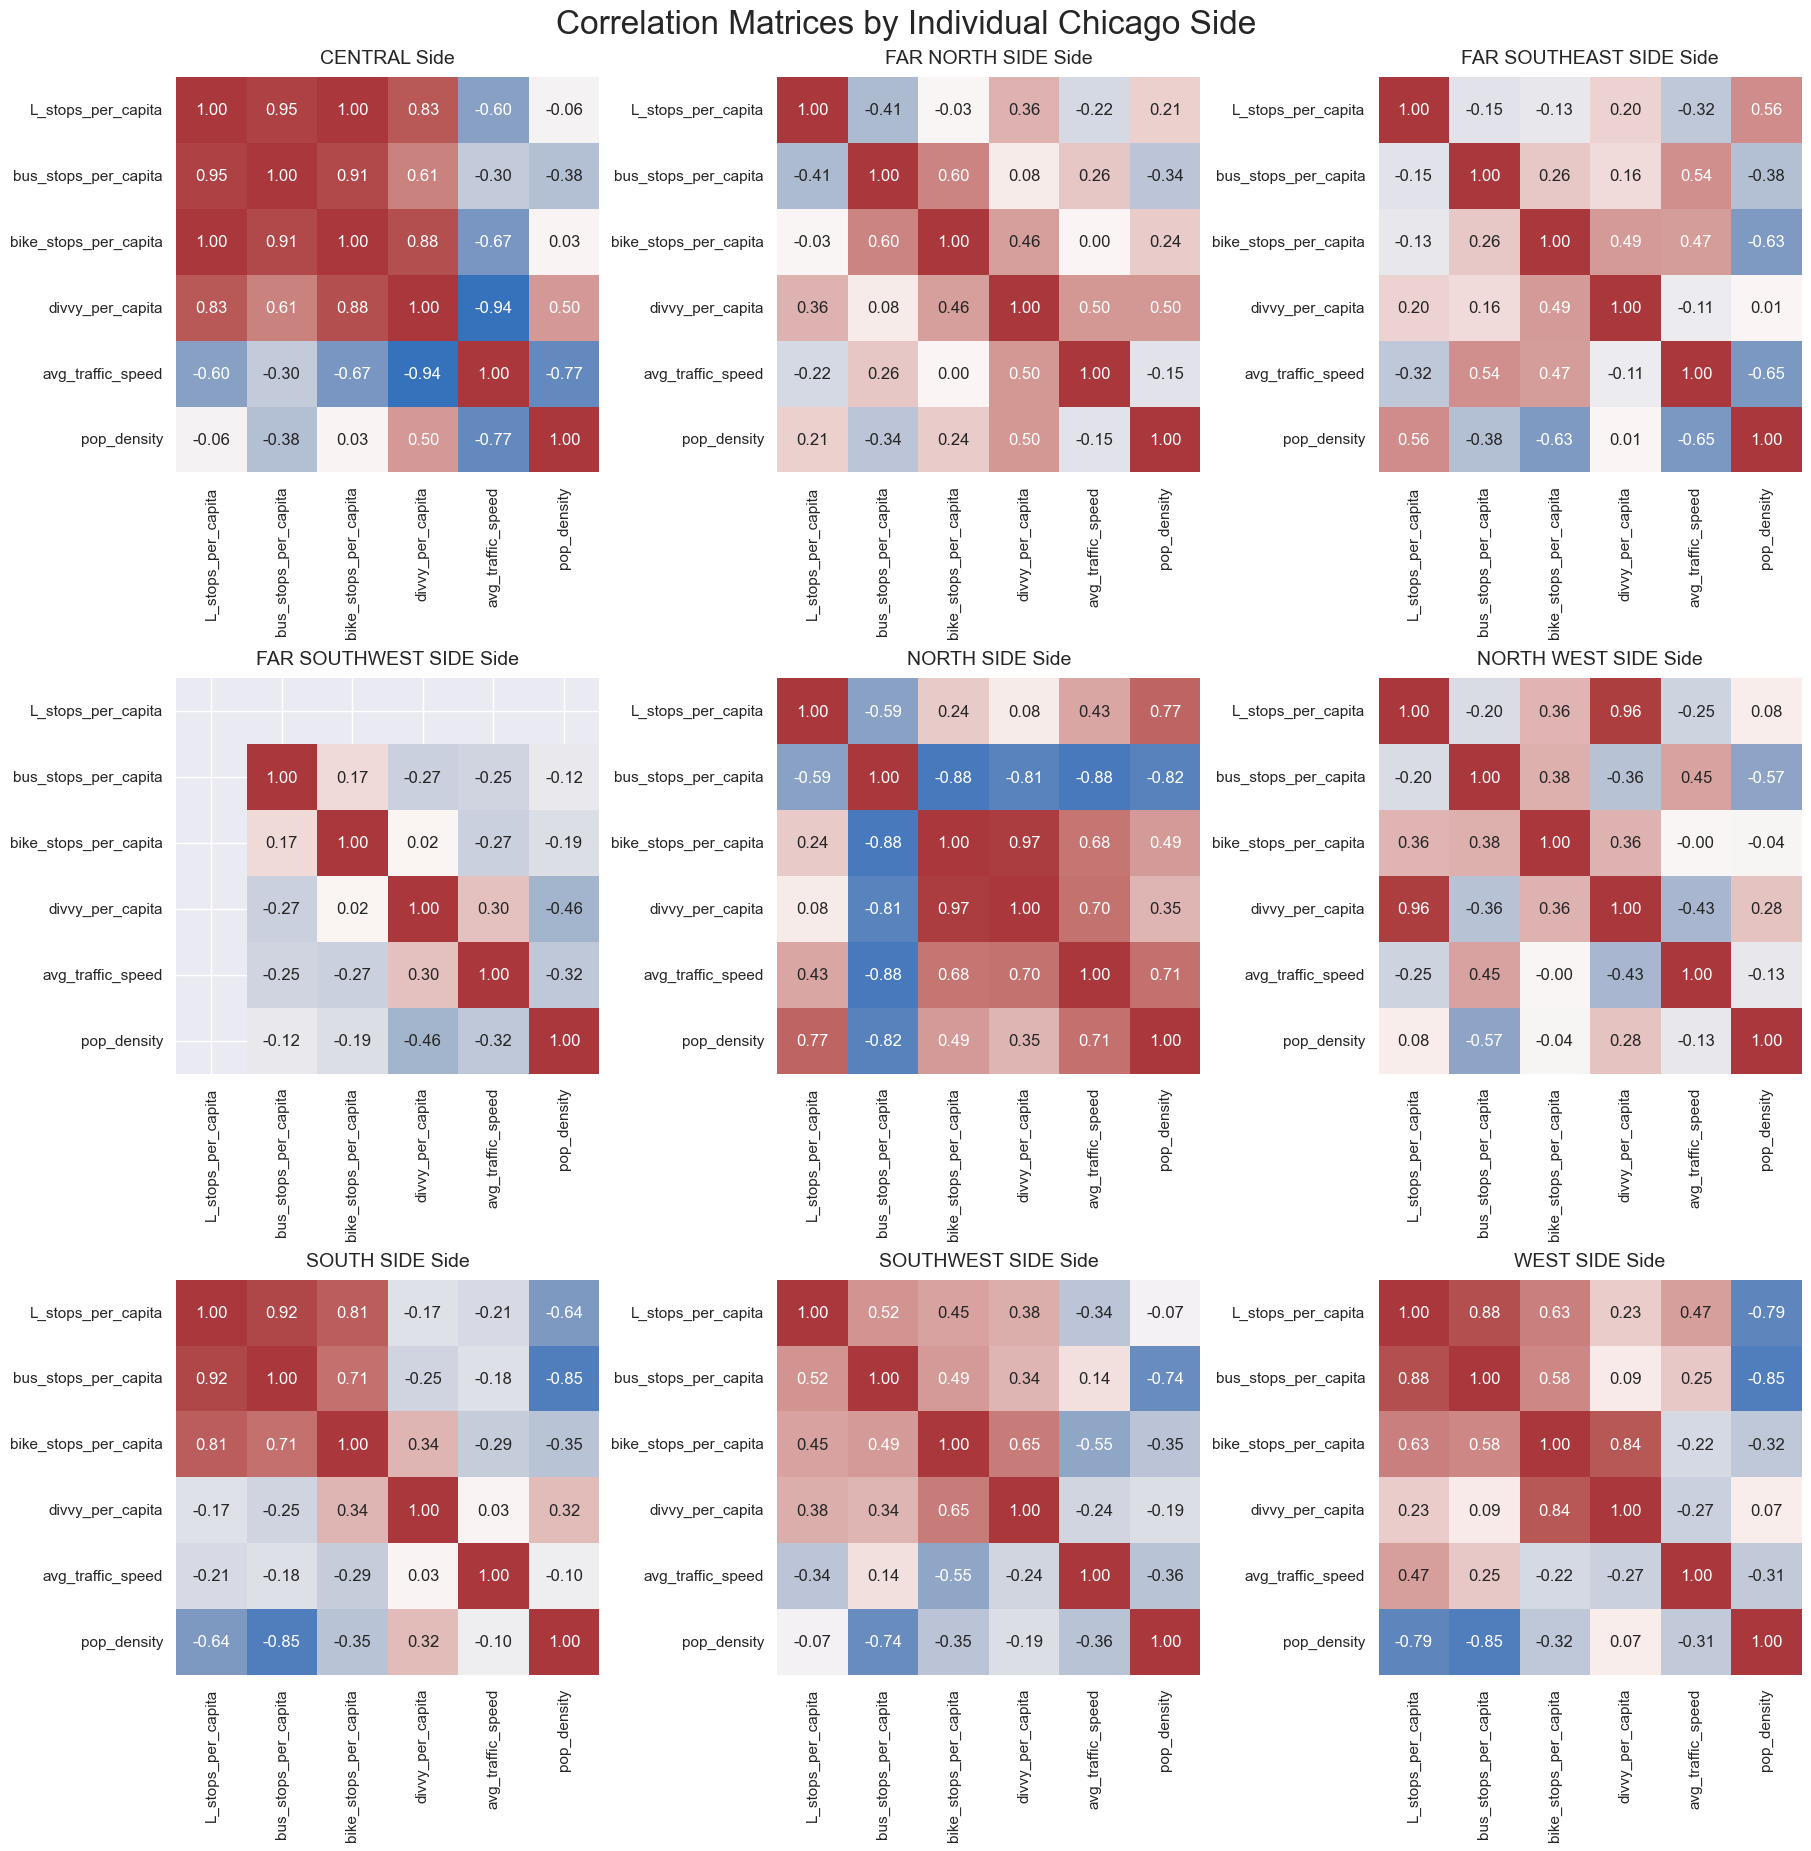

In [236]:
#finding per capita cols
pc_cols = [col for col in merged.columns 
           if 'per_capita' in col and merged[col].dtype != 'O']

pc_cols = pc_cols+['avg_traffic_speed']
pc_cols = pc_cols+['pop_density']
#pc_cols.remove('traffic_per_capita')

unique_sides = side_data['side'].unique() #listing each side

fig, axes = plt.subplots(3, 3, figsize=(18,18),constrained_layout=True)

axes = axes.flatten() # So we can loop through

for i, side_name in enumerate(unique_sides):
    side_subset = merged[merged['side'] == side_name]

    corr_matrix = side_subset[pc_cols].corr() #subsetting so its per capita only and traffic

    sns.heatmap(corr_matrix, cmap='vlag', annot=True, fmt=".2f", ax=axes[i], cbar=False, vmin=-1, vmax=1)

    axes[i].set_title(f'{side_name} Side', fontsize=14, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.suptitle('Correlation Matrices by Individual Chicago Side', fontsize=24, y=1.02)
plt.show()

Let's go over my questions to see where these inconsistencies hold.
1) Number of L Stops is pretty strongly correlated with number of divvy stops but hardly correlated with more rides per capita. Why? - **SOUTH SIDE, WEST SIDE, NORTH WEST SIDE, FAR NORTH SIDE**
2) Number of bus stops are not correlated with number of bike rides per capita, but # bus stops is correlated with bike stops per capita. Why is that? - **SOUTH SIDE, WEST SIDE, NORTH WEST SIDE, FAR NORTH SIDE**

Great, now we have the communities where the trends are unusual. It's the same 4 communities! Let's look into those. 

First, for general observation, I want to also add a quick population density comparison:

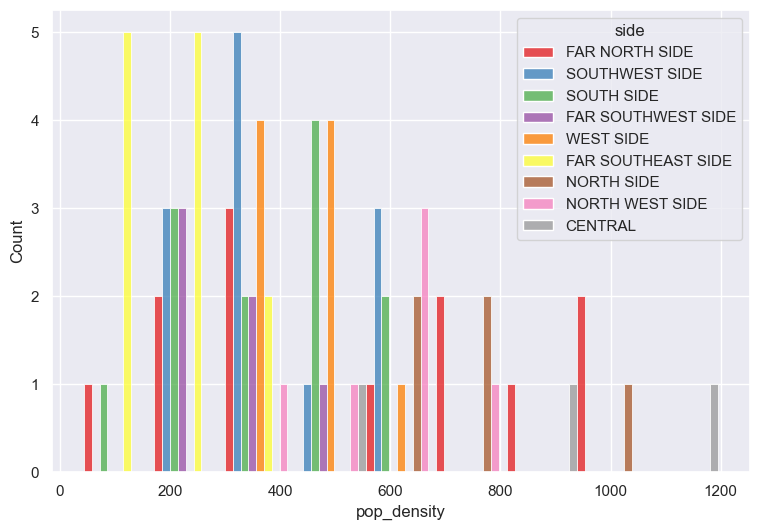

In [237]:
sns.histplot(data=merged, x="pop_density", hue="side", multiple="dodge", palette='Set1');

## South Side

I'd like to see it visually, so I'll make a visual plot I can refer to later

### South Side Map

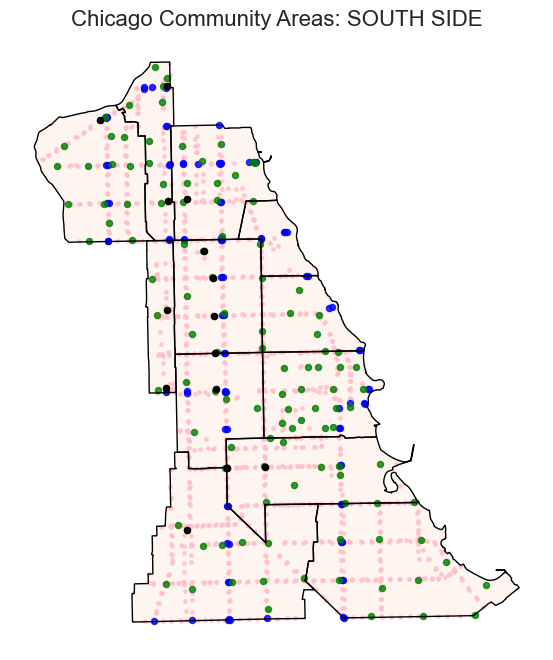

In [238]:
side_to_plot = "SOUTH SIDE"

chicago_one_side = chicago[chicago['side'] == side_to_plot]


fig, ax = plt.subplots(figsize=(10, 8))

chicago_one_side.plot(ax=ax,column='side',cmap='Reds',legend=False) #from above
chicago_one_side.boundary.plot(ax=ax, color='black', linewidth=1)

gdf_points2[gdf_points2.within(chicago_one_side.unary_union)].plot(ax=ax,color='pink',markersize=6,alpha=0.8, label='Bus Stops')
gdf_points1[gdf_points1.within(chicago_one_side.unary_union)].plot(ax=ax,color='blue',markersize=19,alpha=0.8, label='Traffic  Measurements')
gdf_points4[gdf_points4.within(chicago_one_side.unary_union)].plot(ax=ax,color='green',markersize=19,alpha=0.8,label='Bike Stops')
gdf_points3[gdf_points3.within(chicago_one_side.unary_union)].plot(ax=ax,color='black',markersize=19,alpha=0.8, label='L Stops')

#gdf_points[gdf_points.within(chicago_one_side.unary_union)].plot(ax=ax,color='grey',markersize=6,alpha=0.8,label='Bike Ride Start Points')

ax.set_axis_off()
plt.title(f'Chicago Community Areas: {side_to_plot}', fontsize=16)
plt.show()

### South Side Dataframe

In [239]:
south_side_df = merged[merged['side'] == 'SOUTH SIDE']
south_side_df.head()

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side,speed_bin
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE,medium
10,BRIDGEPORT,33012.0,1.0,114,14.0,49980,24.200,0.000030,0.003453,0.000424,1.513995,58.291519,566.325950,SOUTH SIDE,medium
17,DOUGLAS,18629.0,1.0,104,12.0,119180,29.875,0.000054,0.005583,0.000644,6.397552,46.004621,404.937581,SOUTH SIDE,racing
25,FULLER PARK,2186.0,2.0,44,3.0,2364,26.000,0.000915,0.020128,0.001372,1.081427,19.916705,109.757112,SOUTH SIDE,fast
28,GRAND BOULEVARD,24808.0,4.0,126,10.0,14187,21.000,0.000161,0.005079,0.000403,0.571872,48.492503,511.584232,SOUTH SIDE,crawl


Okay now I have a south side dataframe and a visual reference for it. The south side trends that are interesting are (once again):
1) Number of L Stops is very strongly positively correlated with number of divvy stops but hardly correlated (and negatively) with more rides per capita. Why?
2) Number of bus stops are not correlated with number of bike rides per capita, but # bus stops is correlated with bike stops per capita. Why is that? - **SOUTH SIDE, WEST SIDE, NORTH WEST SIDE, FAR NORTH SIDE**

- I would assume divvy stops per cap vs divvy rides per cap would be closely related - and they are overall (pretty strong positive relationship of 0.65 in the main one) and decently related in the South Side (0.34)
- In these areas, L stops per capita, Bus Stops per capita are almost not correlated at all with divvy per capita, though I'd assume they should be. 

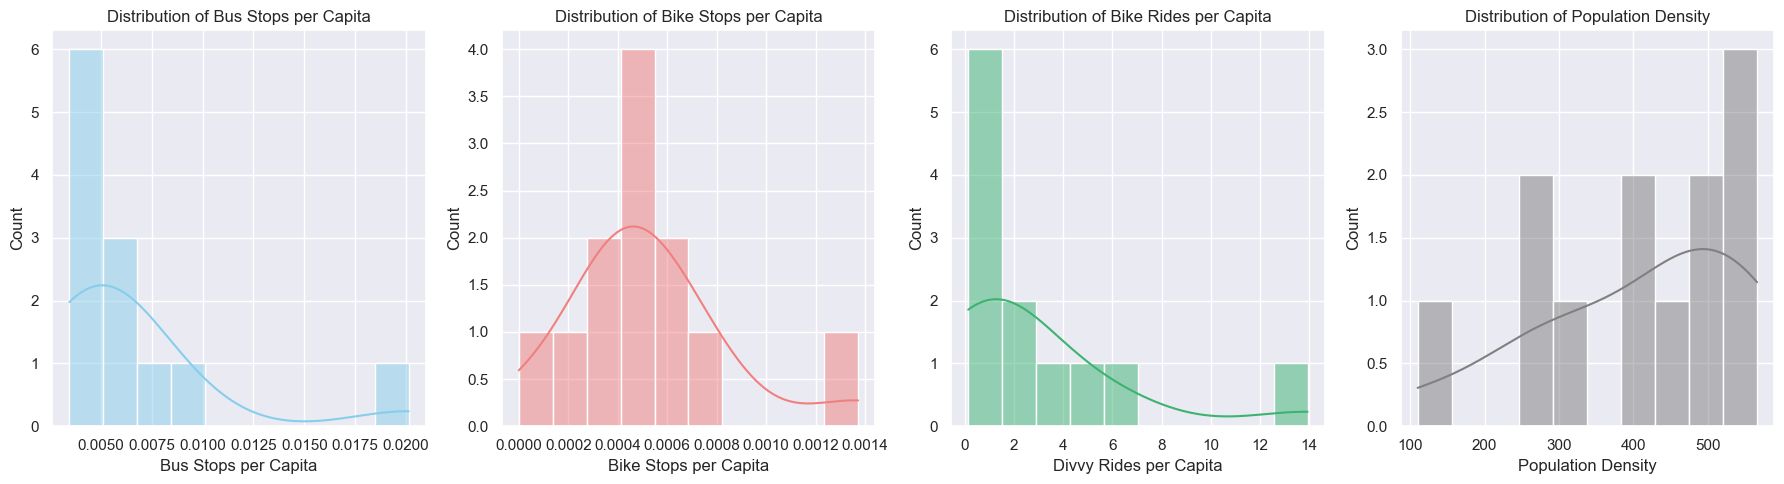

In [240]:
#first, let's visualize distributions: 
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.histplot(data=south_side_df, x="bus_stops_per_capita", ax=axes[0], kde=True, bins=10, color='skyblue')
axes[0].set_title("Distribution of Bus Stops per Capita")
axes[0].set_xlabel("Bus Stops per Capita")

sns.histplot(data=south_side_df, x="bike_stops_per_capita", ax=axes[1], kde=True, bins=10, color='lightcoral')
axes[1].set_title("Distribution of Bike Stops per Capita")
axes[1].set_xlabel("Bike Stops per Capita")

sns.histplot(data=south_side_df, x="divvy_per_capita", ax=axes[2], kde=True, bins=10, color='mediumseagreen')
axes[2].set_title("Distribution of Bike Rides per Capita")
axes[2].set_xlabel("Divvy Rides per Capita")

sns.histplot(data=south_side_df, x="pop_density", ax=axes[3], kde=True, bins=10, color='grey')
axes[3].set_title("Distribution of Population Density")
axes[3].set_xlabel("Population Density")

plt.tight_layout();

This population density is medium/high in comparison to other neighborhoods, just visually compared to the graph above. 

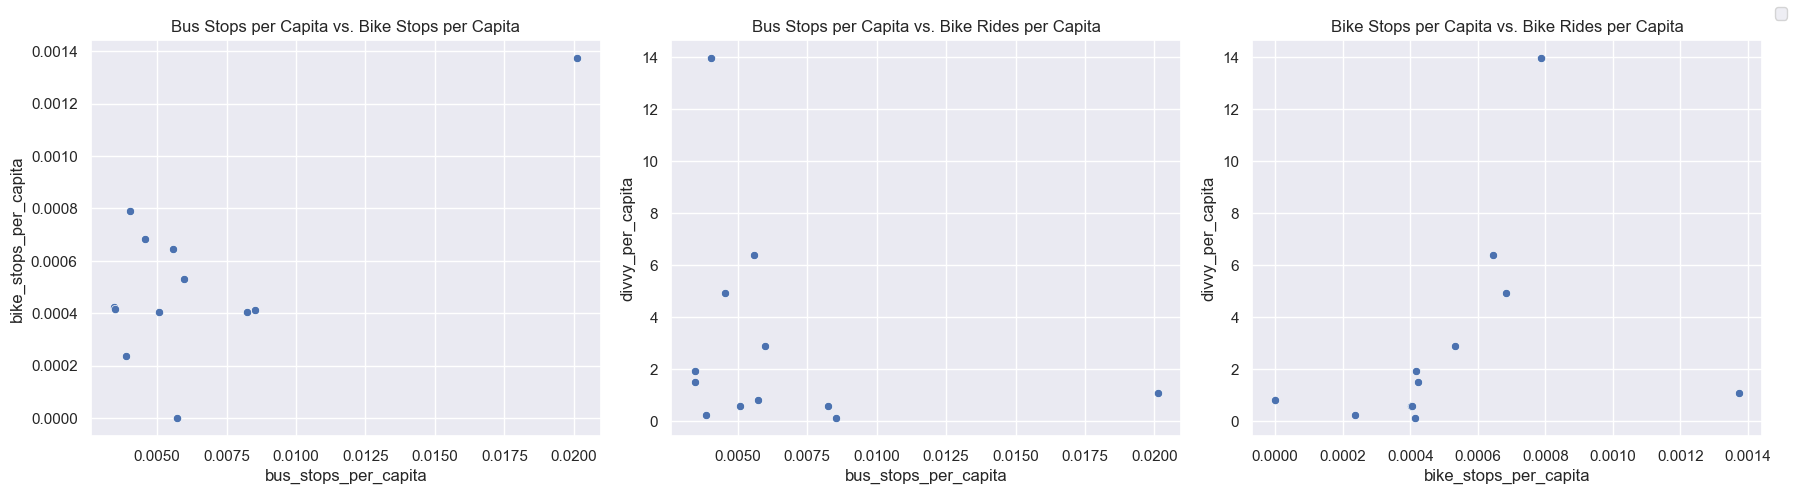

In [241]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False, )

#Bike stops
sns.scatterplot(data=south_side_df,x="bus_stops_per_capita",y="bike_stops_per_capita",ax=axes[0])
axes[0].set_title("Bus Stops per Capita vs. Bike Stops per Capita")
axes[0].legend().remove()

#Bike rides
sns.scatterplot(data=south_side_df,x="bus_stops_per_capita",y="divvy_per_capita",ax=axes[1])
axes[1].set_title("Bus Stops per Capita vs. Bike Rides per Capita")
axes[1].legend().remove()

#stops vs rides
sns.scatterplot(data=south_side_df,x="bike_stops_per_capita",y="divvy_per_capita",ax=axes[2])
axes[2].set_title("Bike Stops per Capita vs. Bike Rides per Capita")
axes[2].legend().remove()

ax.set_xscale('log')
ax.set_yscale('log')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout();

<Axes: ylabel='Frequency'>

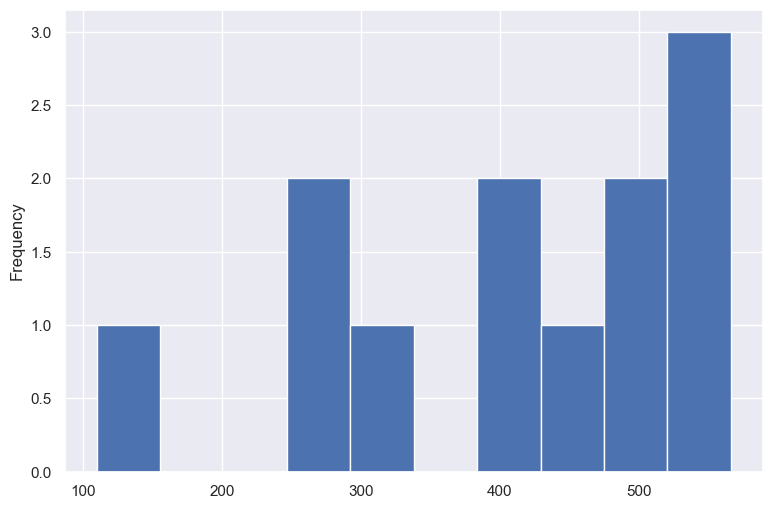

In [242]:
south_side_df.pop_density.plot.hist()

q

q

q
q

q

q


q
q



q
q

q


q


q

q

q


q


q



q


q

q

q


q

### Question 1: L stops vs. Divvy stops and Divvy rides (all per capita)
- I would assume divvy stops per cap vs divvy rides per cap would be closely related - and they are overall (pretty strong positive relationship of 0.65 in the main one)
        - this trend holds on the West Side and slightly on the Far North Side, but is reversed on the South Side and pretty weak on the West side
- In these areas, L stops per capita and divvy per capita are almost not correlated at all  
- Let's explore this further

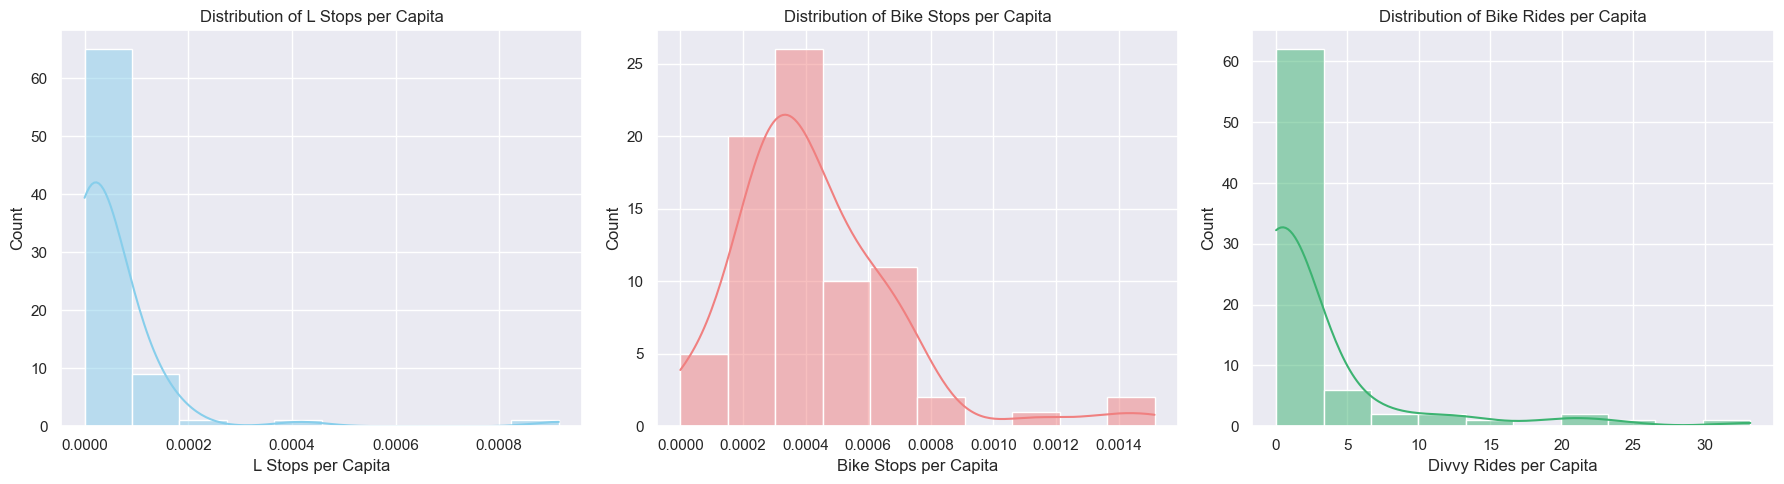

In [243]:
#first, let's visualize distributions: 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=merged, x="L_stops_per_capita", ax=axes[0], kde=True, bins=10, color='skyblue')
axes[0].set_title("Distribution of L Stops per Capita")
axes[0].set_xlabel("L Stops per Capita")

sns.histplot(data=merged, x="bike_stops_per_capita", ax=axes[1], kde=True, bins=10, color='lightcoral')
axes[1].set_title("Distribution of Bike Stops per Capita")
axes[1].set_xlabel("Bike Stops per Capita")

sns.histplot(data=merged, x="divvy_per_capita", ax=axes[2], kde=True, bins=10, color='mediumseagreen')
axes[2].set_title("Distribution of Bike Rides per Capita")
axes[2].set_xlabel("Divvy Rides per Capita")

plt.tight_layout();

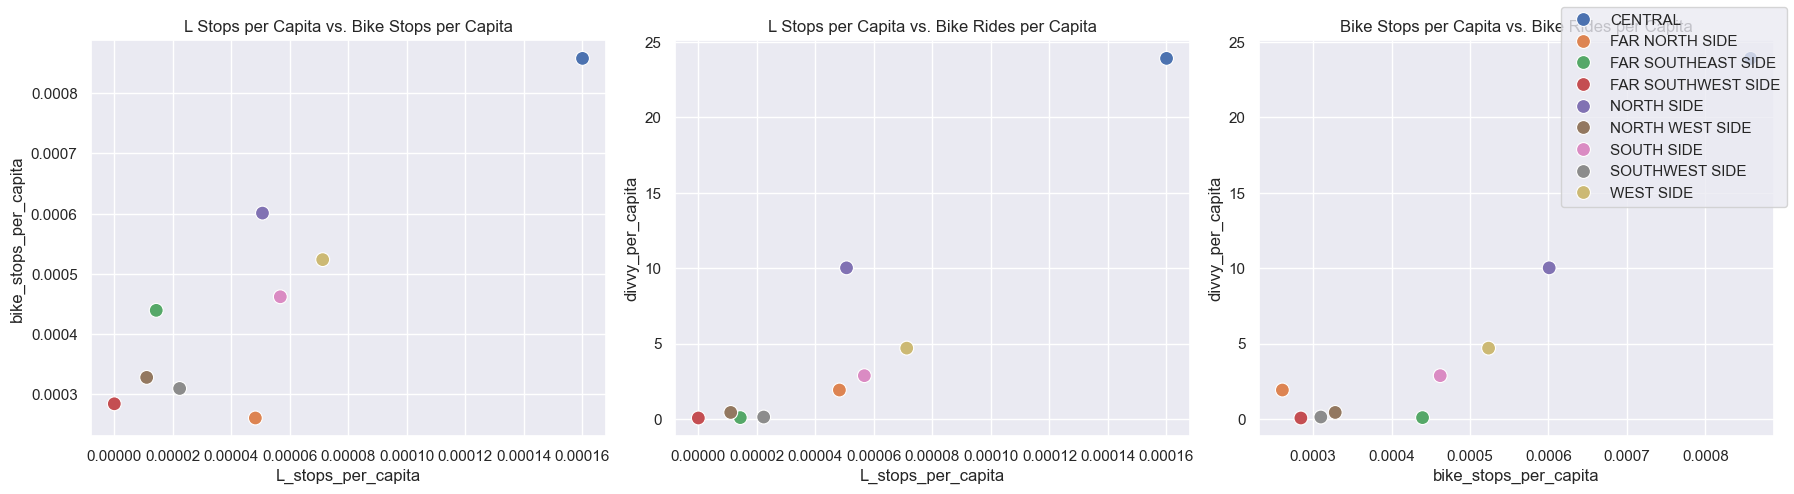

In [244]:
#now, let's see where our outliers are (I have a feeling it will be mostly central)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

#Bike stops
sns.scatterplot(data=side_data,x="L_stops_per_capita",y="bike_stops_per_capita",hue="side",s=100,ax=axes[0])
axes[0].set_title("L Stops per Capita vs. Bike Stops per Capita")
axes[0].legend().remove()

#Bike rides
sns.scatterplot(data=side_data,x="L_stops_per_capita",y="divvy_per_capita",hue="side",s=100,ax=axes[1])
axes[1].set_title("L Stops per Capita vs. Bike Rides per Capita")
axes[1].legend().remove()

#stops vs rides
sns.scatterplot(data=side_data,x="bike_stops_per_capita",y="divvy_per_capita",hue="side",s=100,ax=axes[2])
axes[2].set_title("Bike Stops per Capita vs. Bike Rides per Capita")
axes[2].legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout();

Okay, looks like my instincts were right... central region has a lot of outliers. I think maybe I should analyze 

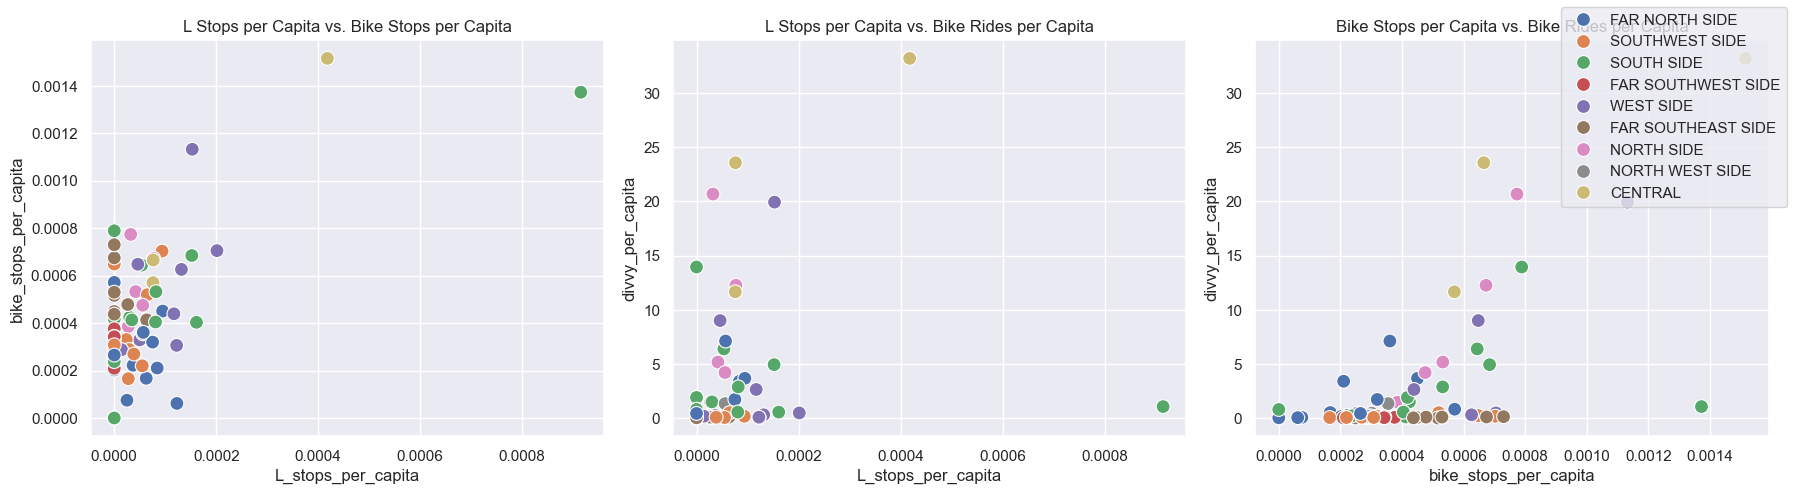

In [245]:
# First let's visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

#Bike stops
sns.scatterplot(data=merged,x="L_stops_per_capita",y="bike_stops_per_capita",hue="side",s=100,ax=axes[0])
axes[0].set_title("L Stops per Capita vs. Bike Stops per Capita")
axes[0].legend().remove()

#Bike rides
sns.scatterplot(data=merged,x="L_stops_per_capita",y="divvy_per_capita",hue="side",s=100,ax=axes[1])
axes[1].set_title("L Stops per Capita vs. Bike Rides per Capita")
axes[1].legend().remove()

sns.scatterplot(data=merged,x="bike_stops_per_capita",y="divvy_per_capita",hue="side",s=100,ax=axes[2])
axes[2].set_title("Bike Stops per Capita vs. Bike Rides per Capita")
axes[2].legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout();


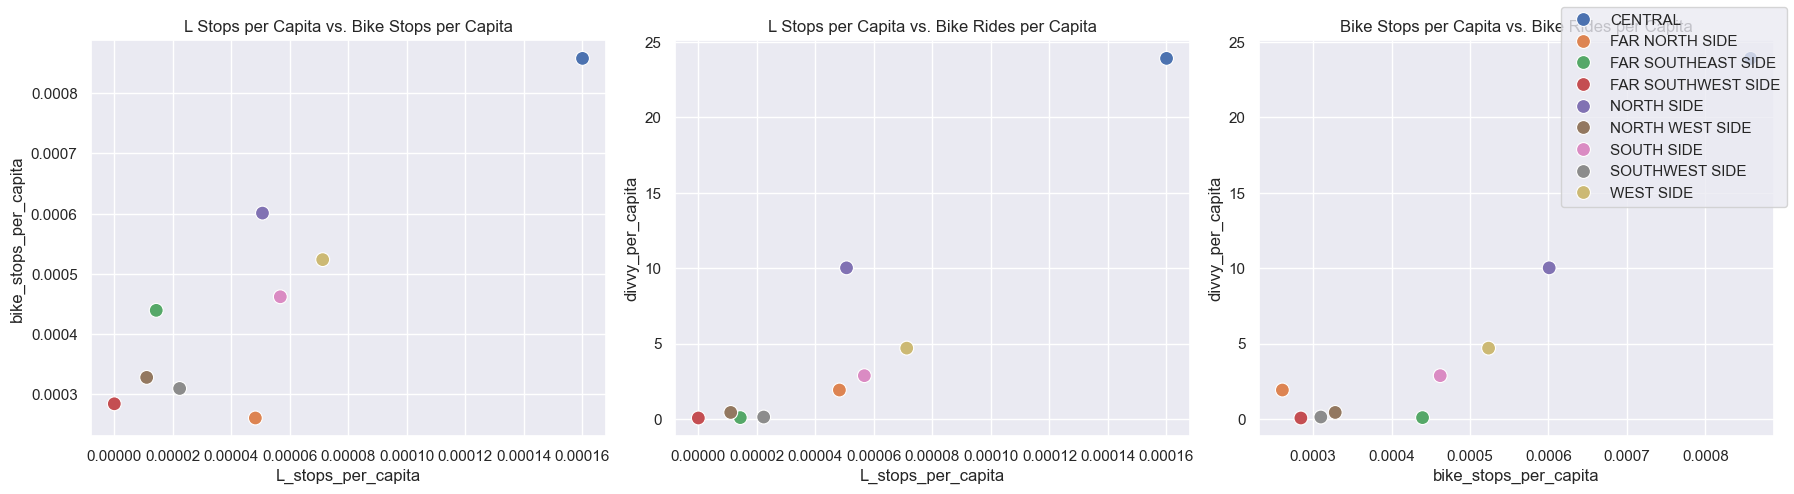

In [246]:
# First let's visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

#Bike stops
sns.scatterplot(data=side_data,x="L_stops_per_capita",y="bike_stops_per_capita",hue="side",s=100,ax=axes[0])
axes[0].set_title("L Stops per Capita vs. Bike Stops per Capita")
axes[0].legend().remove()

#Bike rides
sns.scatterplot(data=side_data,x="L_stops_per_capita",y="divvy_per_capita",hue="side",s=100,ax=axes[1])
axes[1].set_title("L Stops per Capita vs. Bike Rides per Capita")
axes[1].legend().remove()

sns.scatterplot(data=side_data,x="bike_stops_per_capita",y="divvy_per_capita",hue="side",s=100,ax=axes[2])
axes[2].set_title("Bike Stops per Capita vs. Bike Rides per Capita")
axes[2].legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout();

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q

q


### Question 1: Traffic's relationship with Bus Availability.

I'll try to see the distribution graphically. 

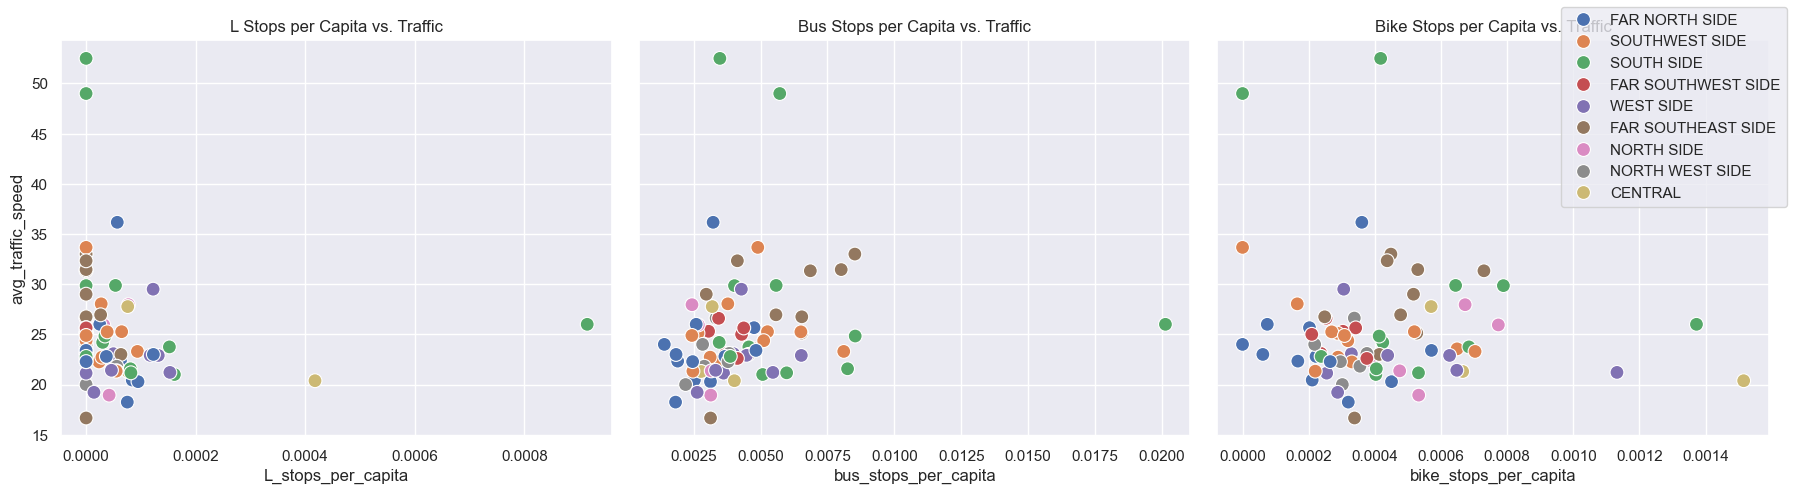

In [247]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=True)

#L stops
sns.scatterplot(data=merged,x="L_stops_per_capita",y="avg_traffic_speed",hue="side",s=100,ax=axes[0])
axes[0].set_title("L Stops per Capita vs. Traffic")
axes[0].legend().remove()

#Bus stops
sns.scatterplot(data=merged,x="bus_stops_per_capita",y="avg_traffic_speed",hue="side",s=100,ax=axes[1])
axes[1].set_title("Bus Stops per Capita vs. Traffic")
axes[1].legend().remove()

#bike stops
sns.scatterplot(data=merged,x="bike_stops_per_capita",y="avg_traffic_speed",hue="side",s=100,ax=axes[2])
axes[2].set_title("Bike Stops per Capita vs. Traffic")
axes[2].legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout();


Okay, this looks confusing, let me bin traffic speed into 5 categories (crawl, slow, medium, fast, racing) maybe

#### Binning Traffic Data

<Axes: ylabel='Frequency'>

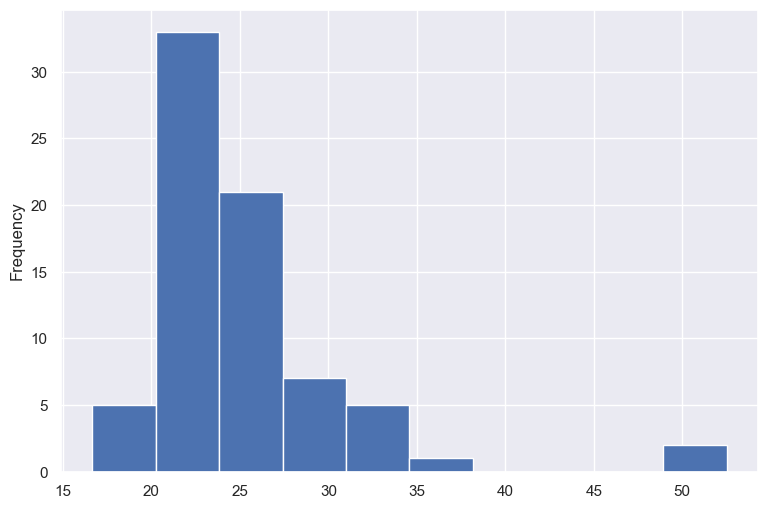

In [248]:
traffic_cleaned_neighb.avg_traffic_speed.plot.hist()

In [249]:
merged_bin = pd.qcut(merged['avg_traffic_speed'],5,labels = ['crawl', 'slow', 'medium', 'fast', 'racing'])

merged['speed_bin'] = merged_bin
merged.head()

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side,speed_bin
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545,FAR NORTH SIDE,slow
1,ARCHER HEIGHTS,13875.0,0.0,66,9.0,3470,23.555556,0.000000,0.004757,0.000649,0.250090,55.922506,248.111200,SOUTHWEST SIDE,medium
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE,medium
3,ASHBURN,42842.0,0.0,131,13.0,2263,25.304348,0.000000,0.003058,0.000303,0.052822,135.460337,316.269699,FAR SOUTHWEST SIDE,fast
4,AUBURN GRESHAM,46483.0,0.0,172,11.0,3112,23.107143,0.000000,0.003700,0.000237,0.066949,105.065354,442.419869,FAR SOUTHWEST SIDE,medium


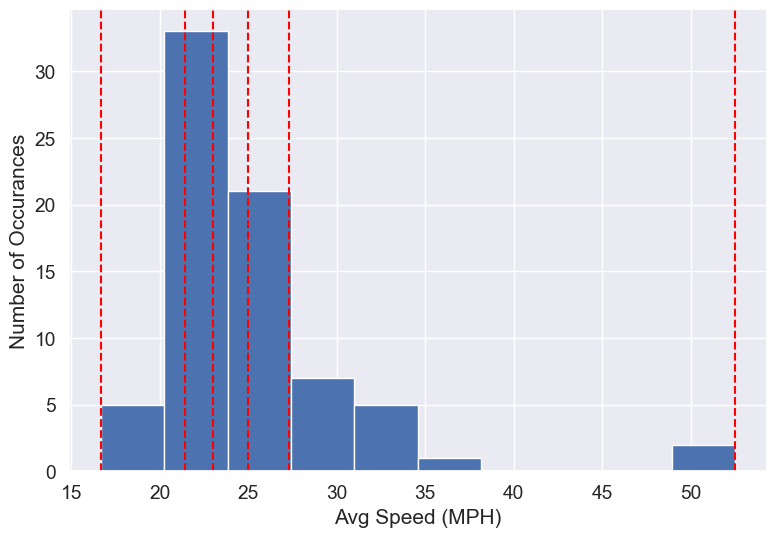

In [250]:
#Visualizing the bins (based on textbook)
int_bin = pd.qcut(merged['avg_traffic_speed'],5)
bin_edges = int_bin.cat.categories

sns.set(font_scale=1.25)
plt.rcParams["figure.figsize"] = (9,6)
ax=traffic_cleaned_neighb.avg_traffic_speed.plot.hist()


for edge in bin_edges.left.tolist() + [bin_edges.right.tolist()[-1]]:
    plt.axvline(edge, color='red', linestyle='--')

plt.xlabel('Avg Speed (MPH)');
plt.ylabel('Number of Occurances');

#### Using the binned data

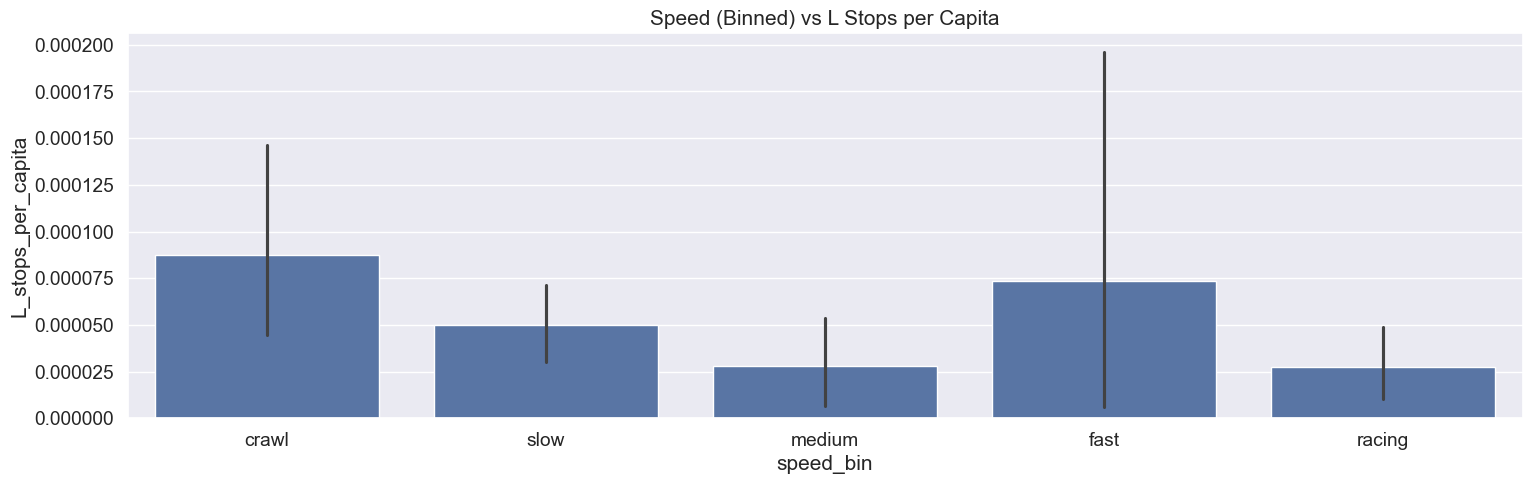

In [251]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Speed (Binned) vs L Stops per Capita')
sns.barplot(x='speed_bin', y='L_stops_per_capita', data=merged);

There's not that many L stops, so the variation is pretty high. 

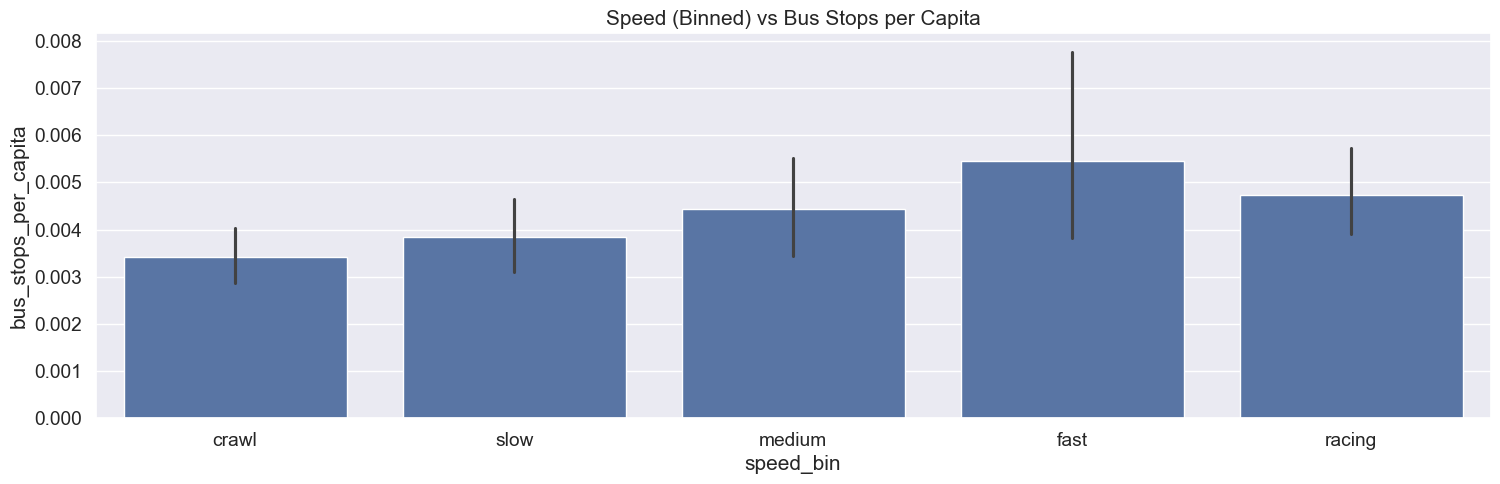

In [252]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Speed (Binned) vs Bus Stops per Capita')
sns.barplot(x='speed_bin', y='bus_stops_per_capita', data=merged);

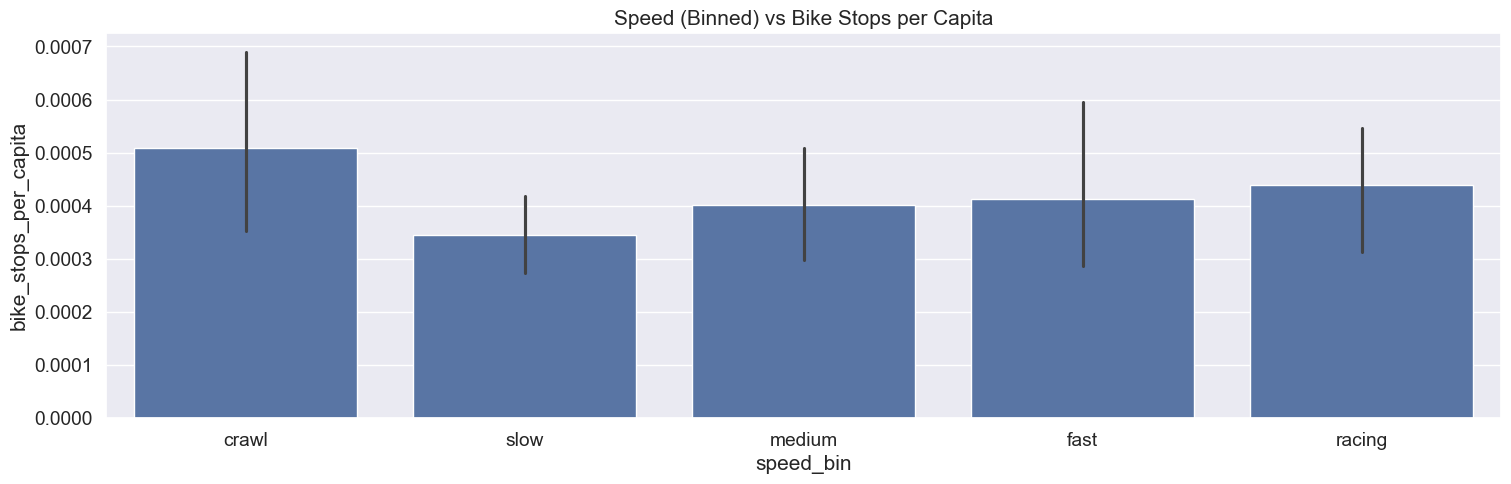

In [253]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Speed (Binned) vs Bike Stops per Capita')
sns.barplot(x='speed_bin', y='bike_stops_per_capita', data=merged);

### Question 2: Why are # of L stops and # of Divvy stops so strongly correlated?

In [254]:
merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side,speed_bin
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545,FAR NORTH SIDE,slow
1,ARCHER HEIGHTS,13875.0,0.0,66,9.0,3470,23.555556,0.000000,0.004757,0.000649,0.250090,55.922506,248.111200,SOUTHWEST SIDE,medium
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE,medium
3,ASHBURN,42842.0,0.0,131,13.0,2263,25.304348,0.000000,0.003058,0.000303,0.052822,135.460337,316.269699,FAR SOUTHWEST SIDE,fast
4,AUBURN GRESHAM,46483.0,0.0,172,11.0,3112,23.107143,0.000000,0.003700,0.000237,0.066949,105.065354,442.419869,FAR SOUTHWEST SIDE,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,0.0,79,10.0,2556,24.888889,0.000000,0.002434,0.000308,0.078765,82.315302,394.228040,SOUTHWEST SIDE,medium
73,WEST PULLMAN,25159.0,0.0,104,11.0,1153,32.333333,0.000000,0.004134,0.000437,0.045829,99.365198,253.197301,FAR SOUTHEAST SIDE,racing
74,WEST RIDGE,79220.0,0.0,195,21.0,35596,22.285714,0.000000,0.002461,0.000265,0.449331,98.429095,804.843325,FAR NORTH SIDE,slow
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143,127.562905,677.728375,WEST SIDE,slow


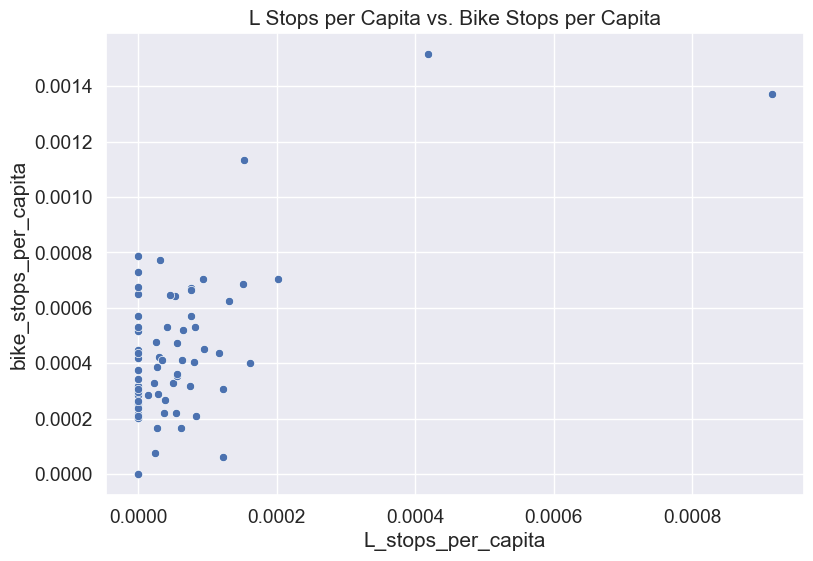

In [255]:
sns.scatterplot(data=merged,x="L_stops_per_capita",y="bike_stops_per_capita")
plt.title("L Stops per Capita vs. Bike Stops per Capita");

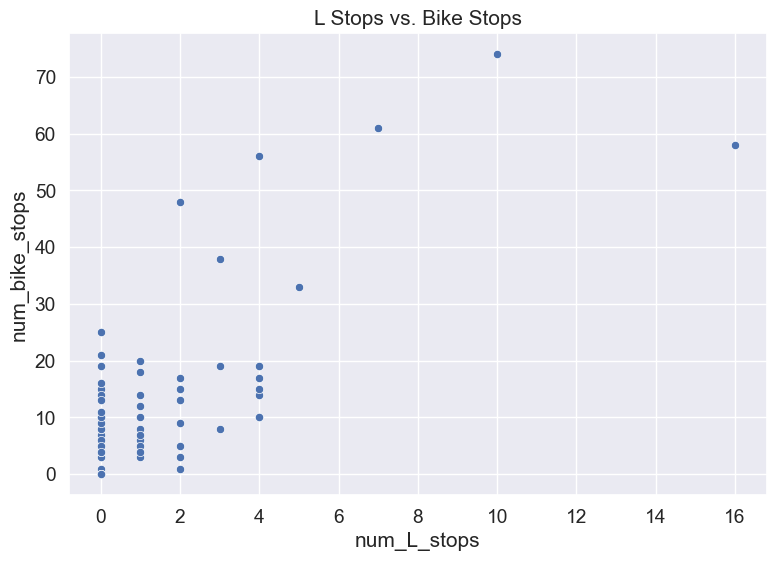

In [256]:
sns.scatterplot(data=merged,x="num_L_stops",y="num_bike_stops")
plt.title("L Stops vs. Bike Stops");

### Question 3: Why are bus stops not correlated with divvy stops, but they are correlated with divvy rides?

Lets 

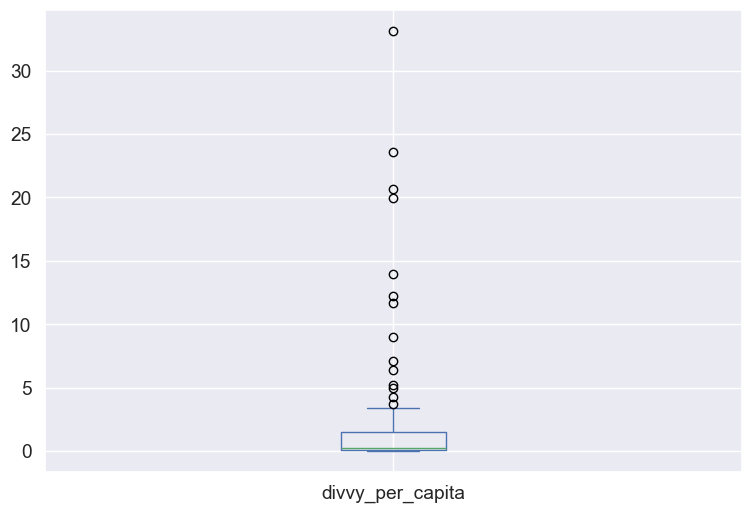

In [257]:
#there are some ride per cap outliers, so I'll remove some

merged.divvy_per_capita.plot(kind='box');

In [258]:
print((merged['divvy_per_capita'] > 15).sum())

4


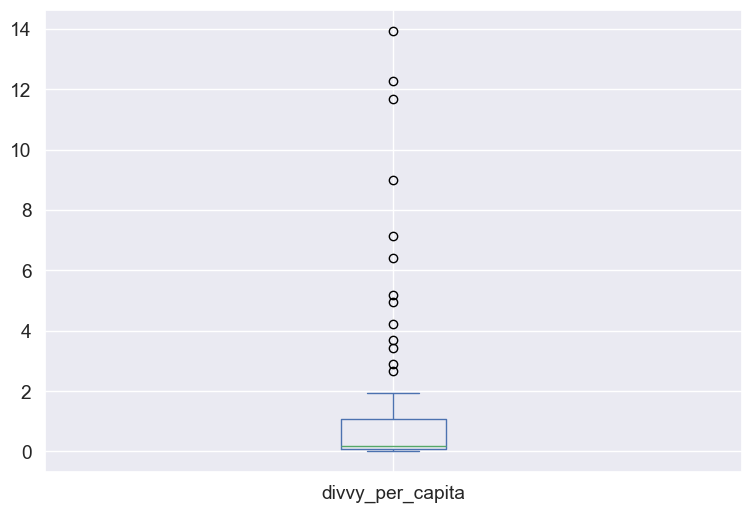

In [259]:
#gonna remove a few outliers (trying not to do many since there's only 77 rows -  is removing 20 rows too many.....
cleaned = merged[merged['divvy_per_capita'] < (15)]
cleaned.divvy_per_capita.plot(kind='box');
#okay this looks reasonable

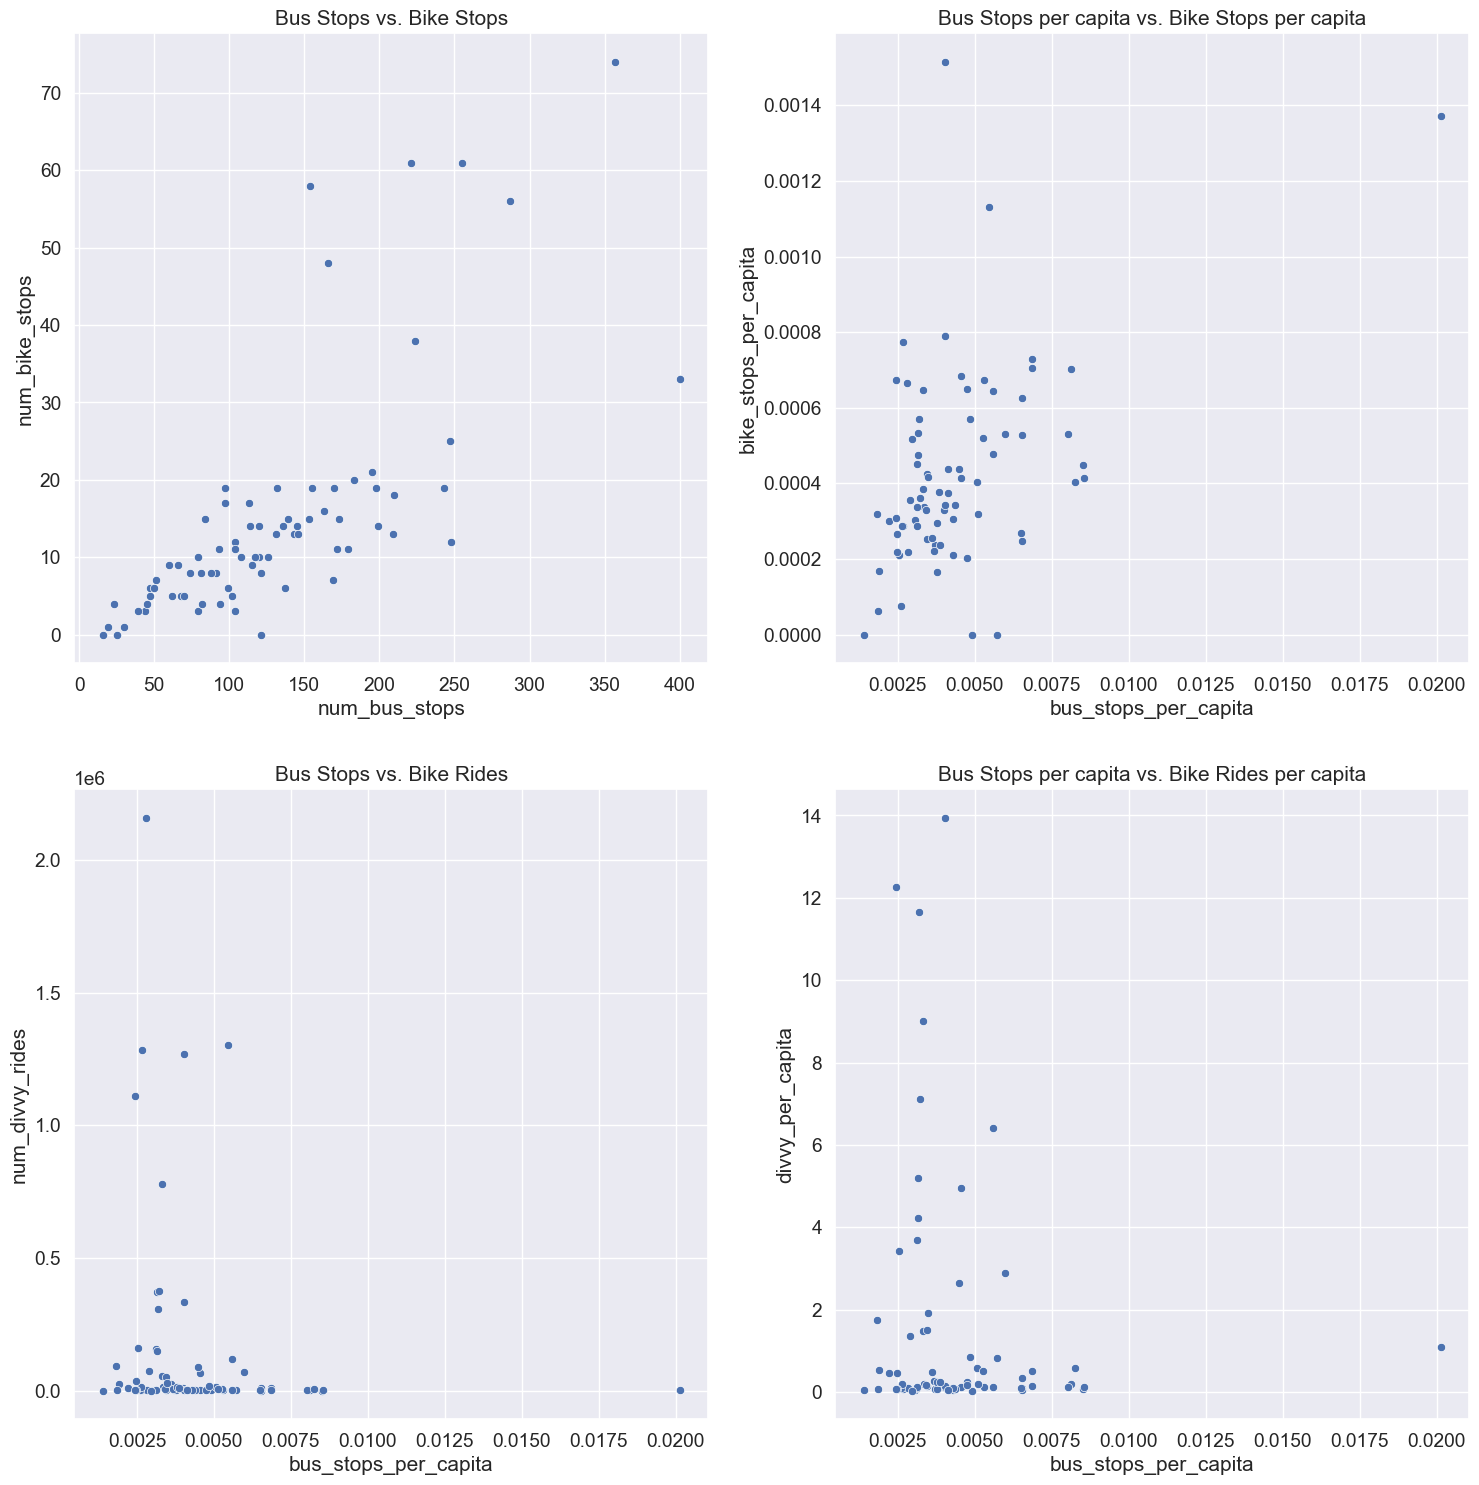

In [260]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18), sharex=False, sharey=False)

sns.scatterplot(data=merged,x="num_bus_stops",y="num_bike_stops", ax=axes[0,0])
axes[0,0].set_title("Bus Stops vs. Bike Stops");

sns.scatterplot(data=merged,x="bus_stops_per_capita",y="bike_stops_per_capita", ax=axes[0,1])
axes[0,1].set_title("Bus Stops per capita vs. Bike Stops per capita");

sns.scatterplot(data=merged,x="bus_stops_per_capita",y="num_divvy_rides", ax=axes[1,0])
axes[1,0].set_title("Bus Stops vs. Bike Rides");

sns.scatterplot(data=cleaned,x="bus_stops_per_capita",y="divvy_per_capita", ax=axes[1,1])
axes[1,1].set_title("Bus Stops per capita vs. Bike Rides per capita");

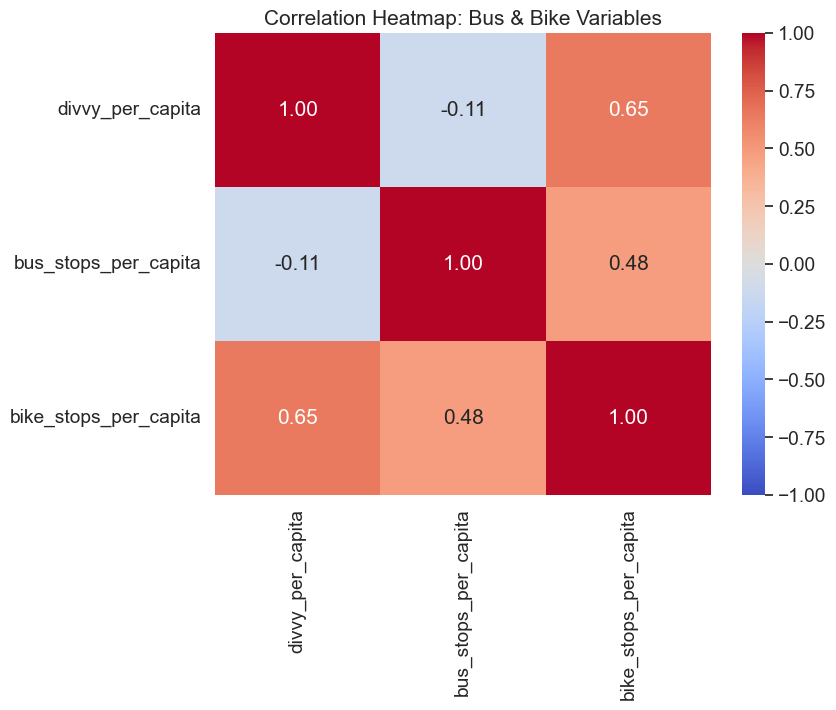

In [261]:
# Select the 4 variables you care about
corr_vars = merged[['divvy_per_capita',
                    'bus_stops_per_capita',
                    'bike_stops_per_capita']]

# Compute correlation matrix
corr_matrix = corr_vars.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin = -1, vmax=1)
plt.title("Correlation Heatmap: Bus & Bike Variables")
plt.show()


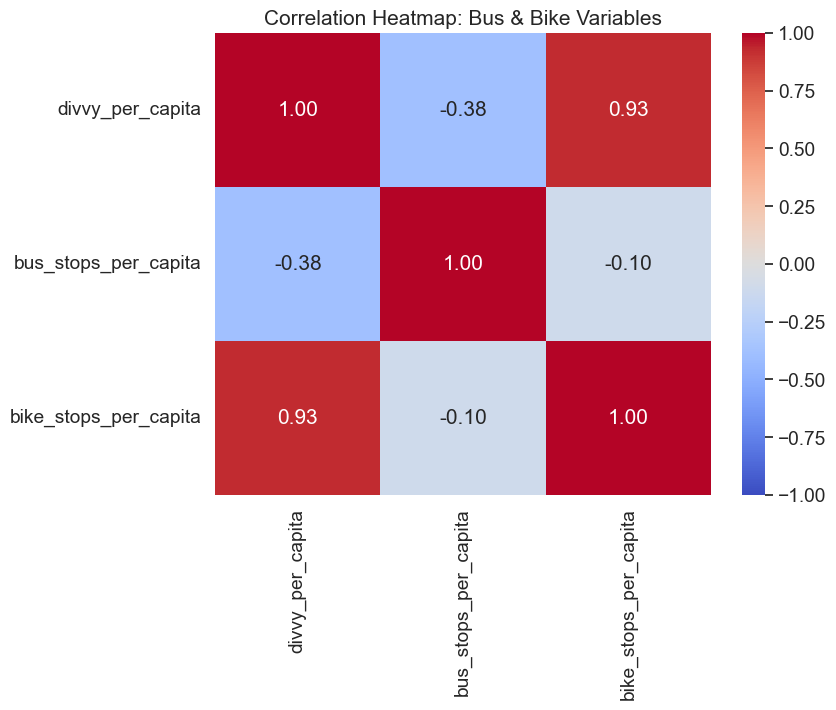

In [262]:
# Select the 4 variables you care about
corr_vars = side_data[['divvy_per_capita',
                    'bus_stops_per_capita',
                    'bike_stops_per_capita']]

# Compute correlation matrix
corr_matrix = corr_vars.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin = -1, vmax=1)
plt.title("Correlation Heatmap: Bus & Bike Variables")
plt.show()

q

q
qq



q
q
q
q



q

q


q

q


q


q



q


q


<Axes: xlabel='bike_stops_per_capita', ylabel='avg_traffic_speed'>

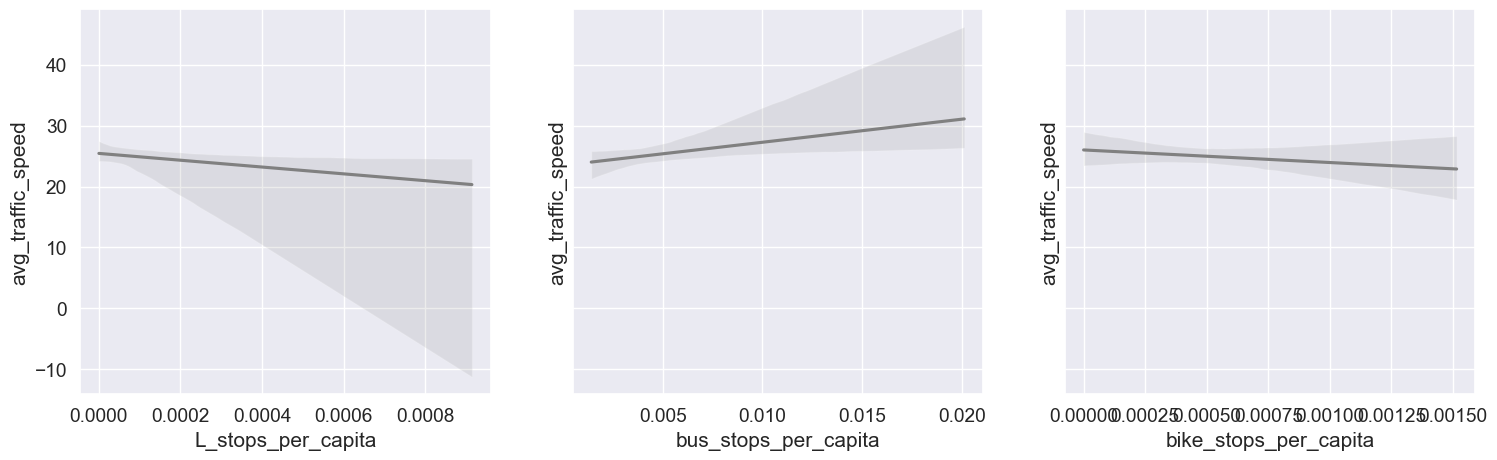

In [263]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=True)

# L stops regression
sns.regplot(data=merged, x="L_stops_per_capita", y="avg_traffic_speed", scatter=False, ax=axes[0], color='gray')

# Bus stops regression
sns.regplot(data=merged, x="bus_stops_per_capita", y="avg_traffic_speed", scatter=False, ax=axes[1], color='gray')

# Bike stops regression
sns.regplot(data=merged, x="bike_stops_per_capita", y="avg_traffic_speed", scatter=False, ax=axes[2], color='gray')


Not sure what do glean from this.

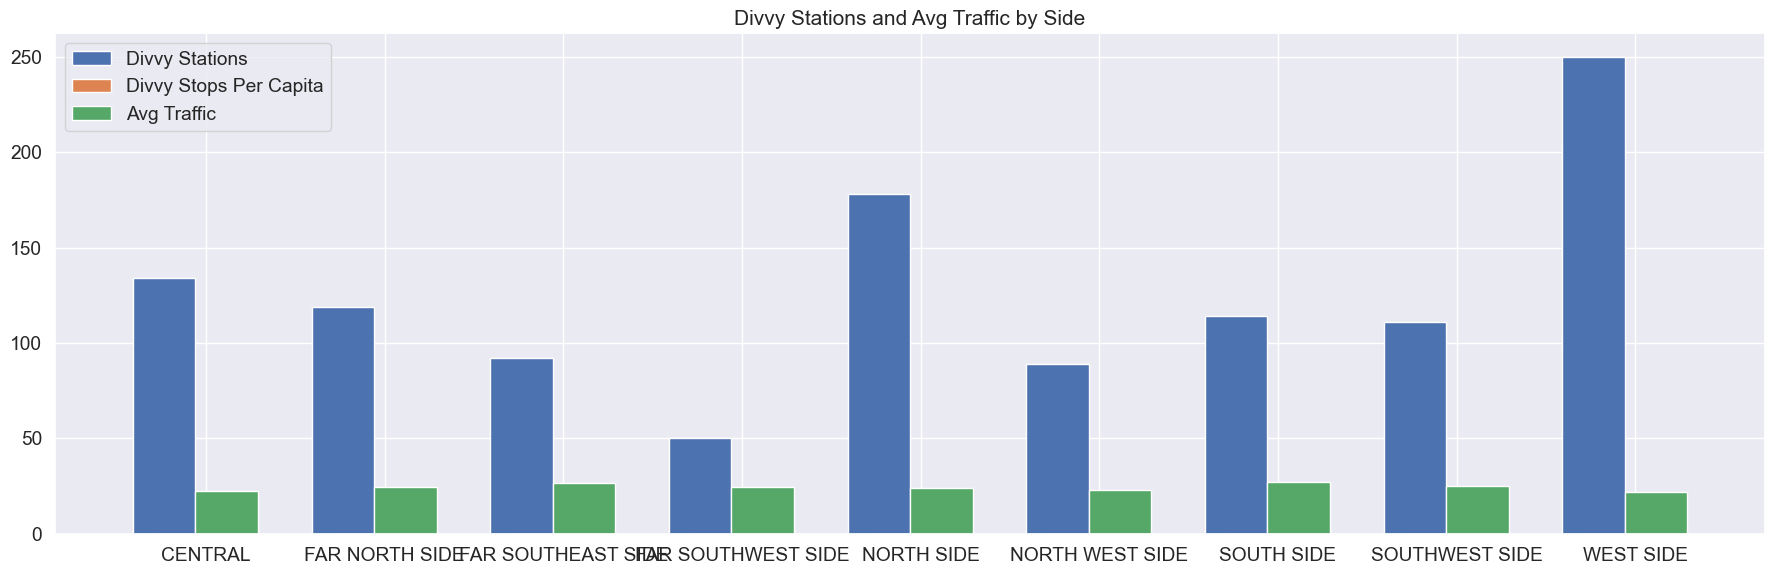

In [264]:
sides = side_data['side']
divvy = side_data['Total_Divvy_Stations']
traffic = side_data['avg_traffic_speed_side']
stops = side_data['bike_stops_per_capita']


x = np.arange(len(sides))
width = 0.35

plt.figure(figsize=(18, 6))
plt.bar(x - 2*(width/3), divvy, width, label='Divvy Stations')
plt.bar(x - width/3, stops, width, label='Divvy Stops Per Capita')
plt.bar(x + width/3, traffic, width, label='Avg Traffic')

plt.xticks(x, sides)
plt.title('Divvy Stations and Avg Traffic by Side')
plt.legend()
plt.tight_layout()
plt.show()

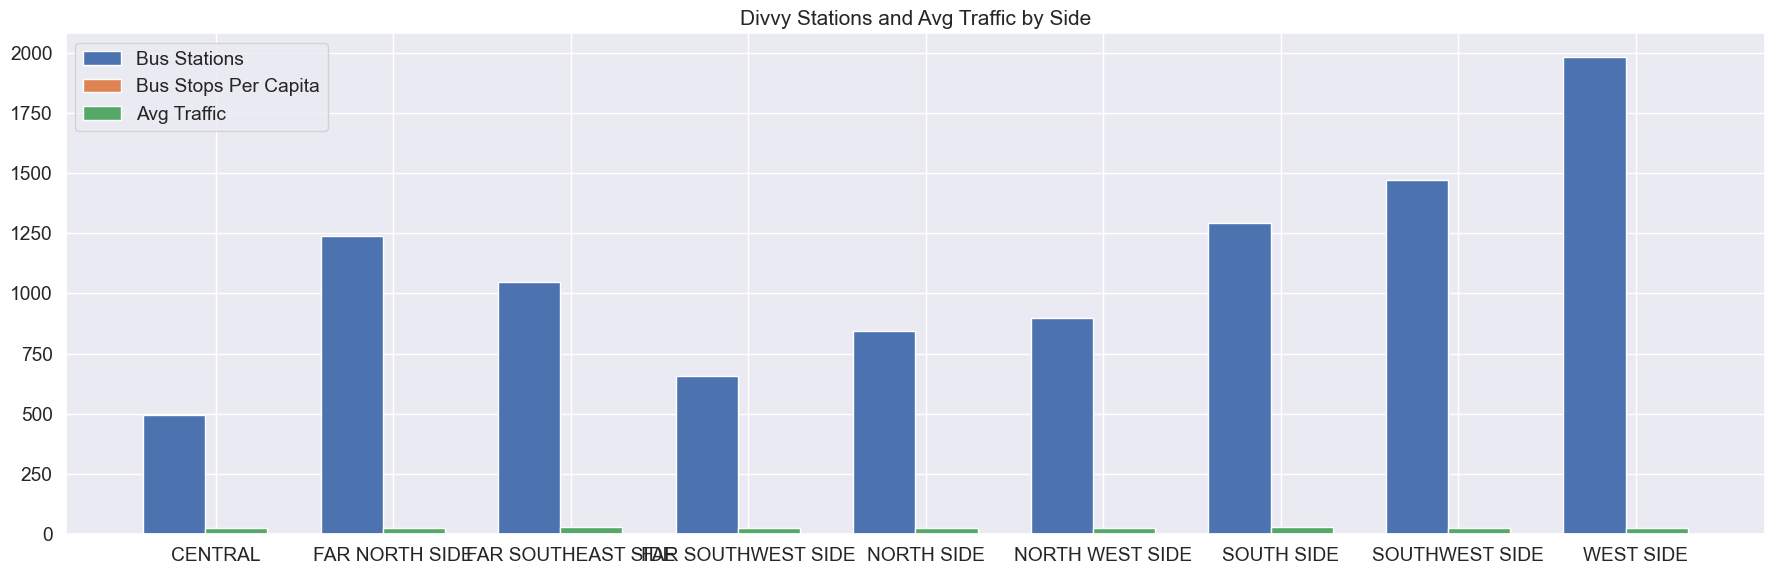

In [265]:
sides = side_data['side']
divvy = side_data['Total_Bus_Stops']
traffic = side_data['avg_traffic_speed_side']
stops = side_data['bus_stops_per_capita']


x = np.arange(len(sides))
width = 0.35

plt.figure(figsize=(18, 6))
plt.bar(x - 2*(width/3), divvy, width, label='Bus Stations')
plt.bar(x - width/3, stops, width, label='Bus Stops Per Capita')
plt.bar(x + width/3, traffic, width, label='Avg Traffic')

plt.xticks(x, sides)
plt.title('Divvy Stations and Avg Traffic by Side')
plt.legend()
plt.tight_layout()
plt.show()

q



q




q





q

q



q

#### Analysis
Highest correlations: 
- L stops and bike stops per capita (areas with more L stops tend to have more divvy stops)
- L stops and bike rides per capita (areas with more L stops tend to have more divvy rides - probably because number of stations correlates with rides)
- Divvy stops and divvy rides per capita (makes sense; more access to rides correlates with more rides)


- we see a strong negative correlation between population and traffic (so keep in mind that areas that are more sparsely populated tend to have higher traffic speed)

### 2: Correlations by "Side" (Per Capita Only)

In [266]:
side_data

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000,0.000160,0.003156,0.000858,23.904132
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000,0.000048,0.002720,0.000261,1.924694
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188,0.000014,0.004997,0.000439,0.097418
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500,0.000000,0.003731,0.000284,0.071866
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808,0.000051,0.002849,0.000601,10.022248
5,NORTH WEST SIDE,271227.0,3.0,898,89.0,119101,22.896552,0.000011,0.003311,0.000328,0.439119
6,SOUTH SIDE,246744.0,14.0,1295,114.0,709917,27.386667,0.000057,0.005248,0.000462,2.877140
7,SOUTHWEST SIDE,358308.0,8.0,1472,111.0,48670,24.884058,0.000022,0.004108,0.000310,0.135833
8,WEST SIDE,477402.0,34.0,1983,250.0,2244765,22.100000,0.000071,0.004154,0.000524,4.702044


This is finding the correlations between each category based on the neighborhods within each side (so comparing the Loop versus the other two neighborhoods in the "CENTRAL" region)

In [267]:
#finding per capita cols
pc_cols = [col for col in merged.columns 
           if 'per_capita' in col and merged[col].dtype != 'O']

pc_cols = pc_cols+['avg_traffic_speed']
#pc_cols.remove('traffic_per_capita')
print(pc_cols)

['L_stops_per_capita', 'bus_stops_per_capita', 'bike_stops_per_capita', 'divvy_per_capita', 'avg_traffic_speed']


In [268]:
side_data.head()

,side,Total_Population,Total_L_Stops,Total_Bus_Stops,Total_Divvy_Stations,Total_Divvy_Rides,avg_traffic_speed_side,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita
0,CENTRAL,156226.0,25.0,493,134.0,3734447,22.500000,0.000160,0.003156,0.000858,23.904132
1,FAR NORTH SIDE,456323.0,22.0,1241,119.0,878282,24.725000,0.000048,0.002720,0.000261,1.924694
2,FAR SOUTHEAST SIDE,209345.0,3.0,1046,92.0,20394,26.623188,0.000014,0.004997,0.000439,0.097418
3,FAR SOUTHWEST SIDE,175841.0,0.0,656,50.0,12637,24.487500,0.000000,0.003731,0.000284,0.071866
4,NORTH SIDE,296205.0,15.0,844,178.0,2968640,23.917808,0.000051,0.002849,0.000601,10.022248


In [269]:
merged

,community,population_avg,num_L_stops,num_bus_stops,num_bike_stops,num_divvy_rides,avg_traffic_speed,L_stops_per_capita,bus_stops_per_capita,bike_stops_per_capita,divvy_per_capita,area_km2,pop_density,side,speed_bin
0,ALBANY PARK,47830.0,3.0,91,8.0,25540,22.333333,0.000063,0.001903,0.000167,0.533974,53.542231,893.313545,FAR NORTH SIDE,slow
1,ARCHER HEIGHTS,13875.0,0.0,66,9.0,3470,23.555556,0.000000,0.004757,0.000649,0.250090,55.922506,248.111200,SOUTHWEST SIDE,medium
2,ARMOUR SQUARE,13149.0,2.0,60,9.0,65029,23.750000,0.000152,0.004563,0.000684,4.945547,27.766196,473.561447,SOUTH SIDE,medium
3,ASHBURN,42842.0,0.0,131,13.0,2263,25.304348,0.000000,0.003058,0.000303,0.052822,135.460337,316.269699,FAR SOUTHWEST SIDE,fast
4,AUBURN GRESHAM,46483.0,0.0,172,11.0,3112,23.107143,0.000000,0.003700,0.000237,0.066949,105.065354,442.419869,FAR SOUTHWEST SIDE,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,32451.0,0.0,79,10.0,2556,24.888889,0.000000,0.002434,0.000308,0.078765,82.315302,394.228040,SOUTHWEST SIDE,medium
73,WEST PULLMAN,25159.0,0.0,104,11.0,1153,32.333333,0.000000,0.004134,0.000437,0.045829,99.365198,253.197301,FAR SOUTHEAST SIDE,racing
74,WEST RIDGE,79220.0,0.0,195,21.0,35596,22.285714,0.000000,0.002461,0.000265,0.449331,98.429095,804.843325,FAR NORTH SIDE,slow
75,WEST TOWN,86453.0,4.0,287,56.0,778781,21.421053,0.000046,0.003320,0.000648,9.008143,127.562905,677.728375,WEST SIDE,slow


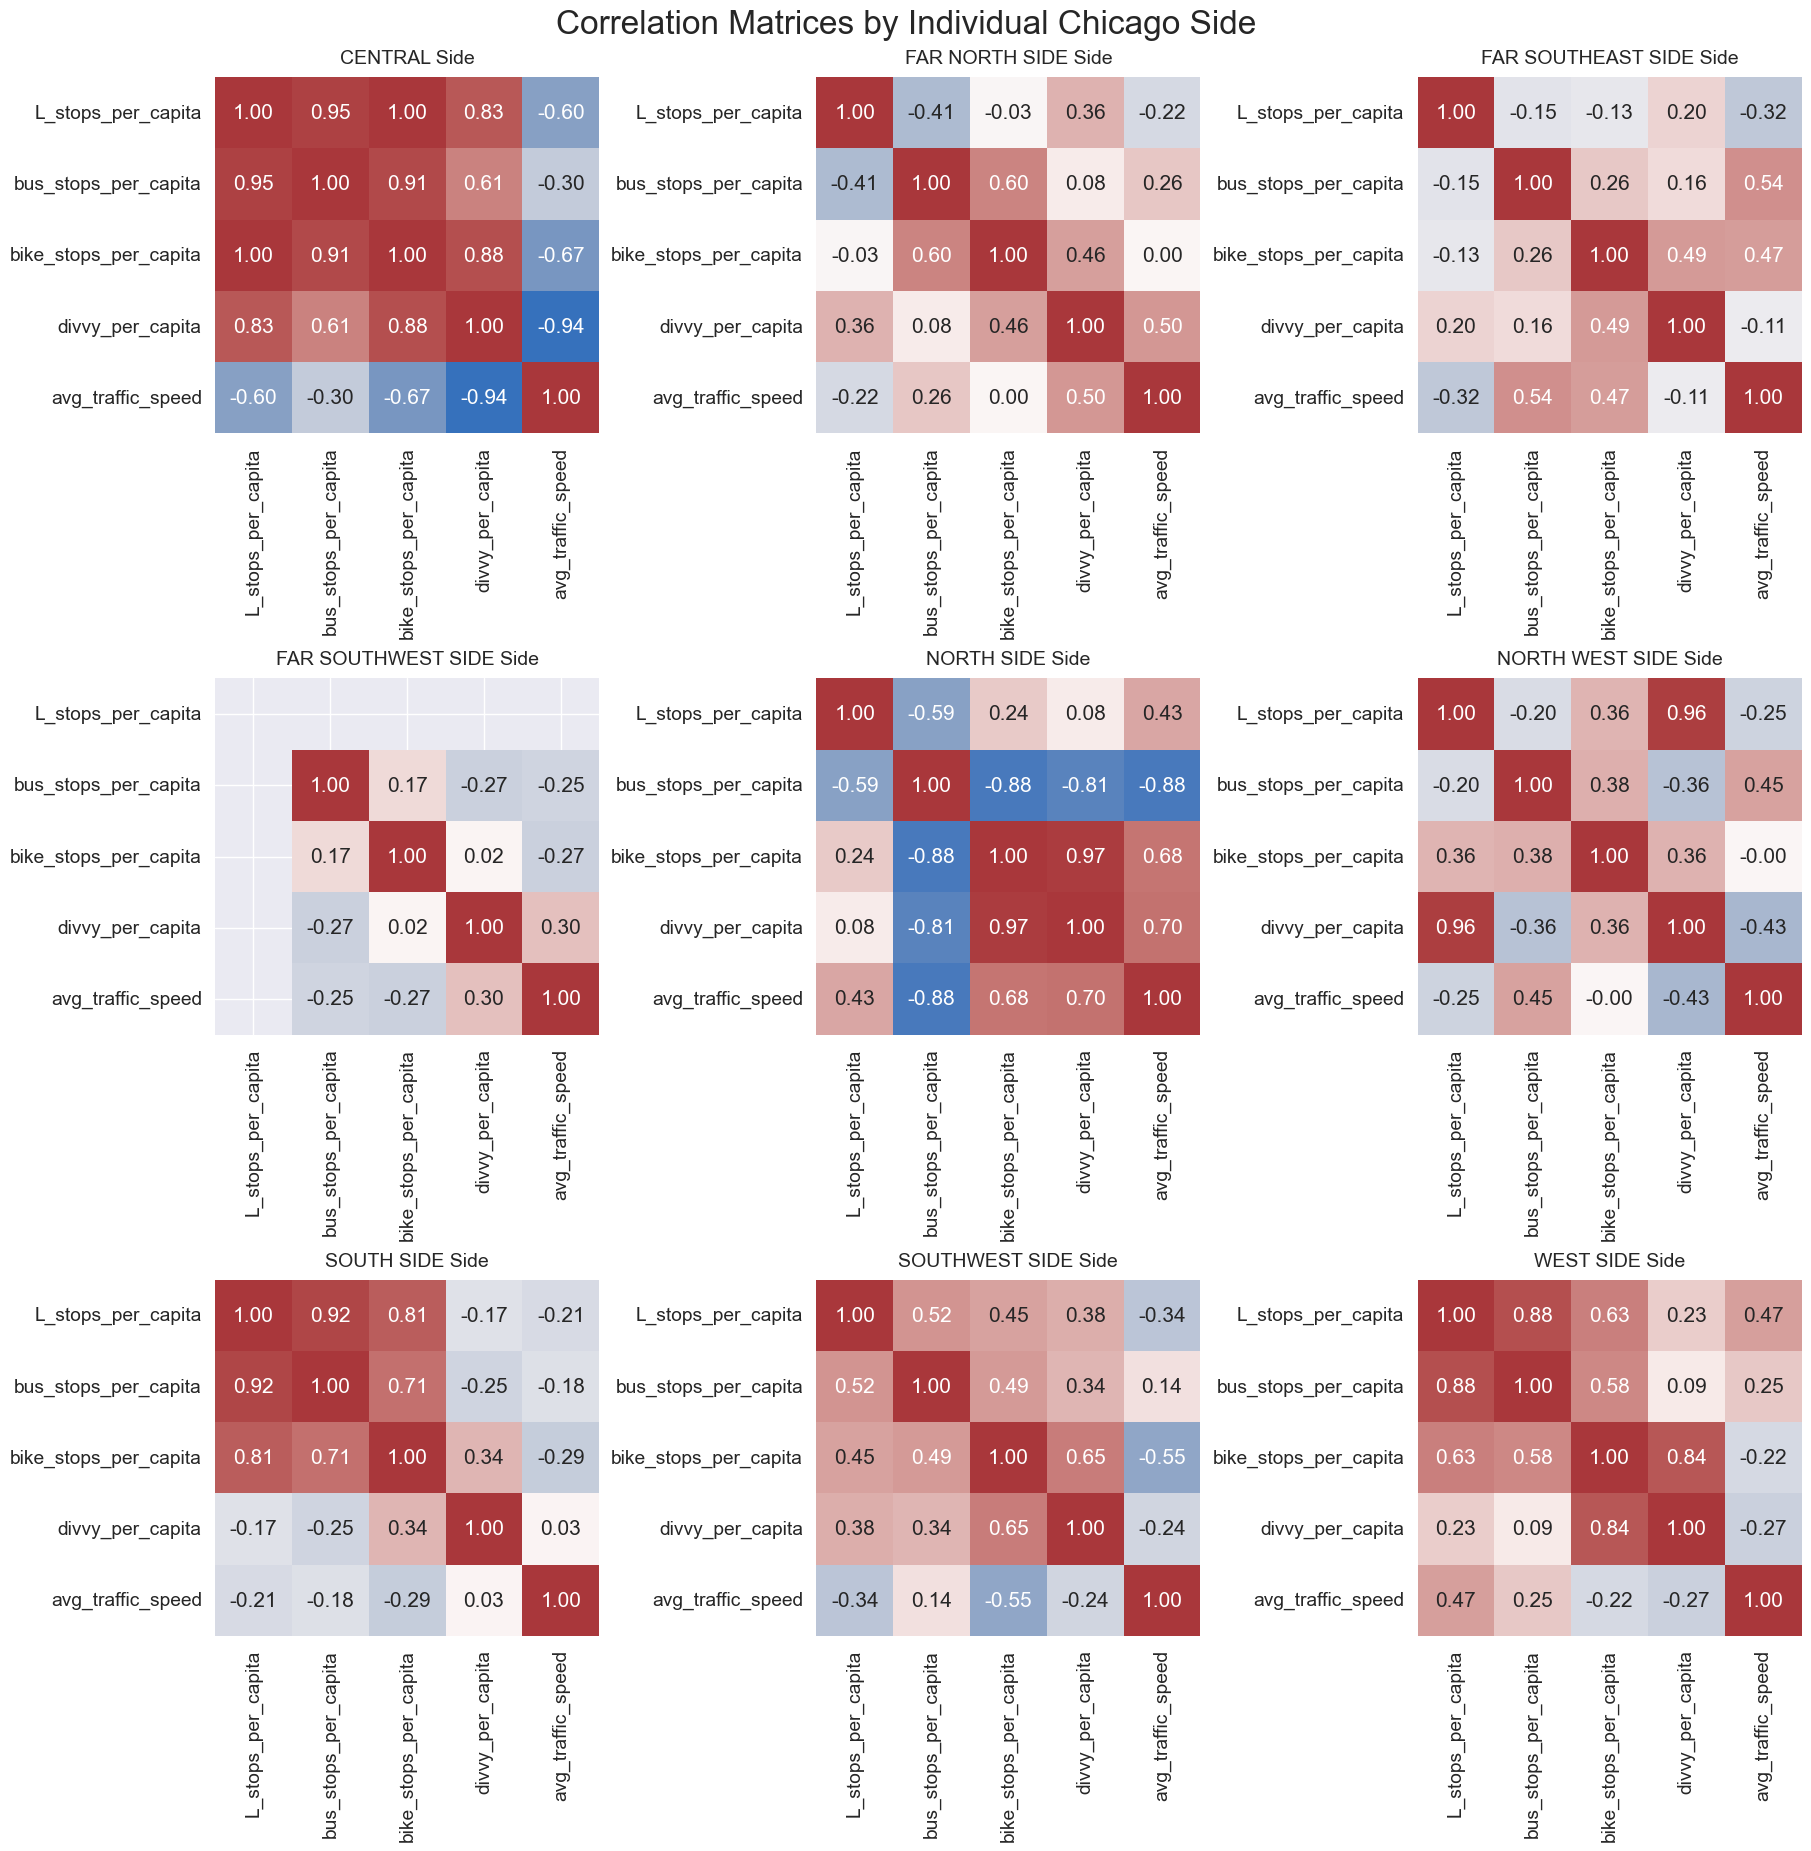

In [270]:
unique_sides = side_data['side'].unique() #listing each side

fig, axes = plt.subplots(3, 3, figsize=(18,18),constrained_layout=True)

axes = axes.flatten() # So we can loop through

for i, side_name in enumerate(unique_sides):
    side_subset = merged[merged['side'] == side_name]

    corr_matrix = side_subset[pc_cols].corr() #subsetting so its per capita only

    sns.heatmap(corr_matrix, cmap='vlag', annot=True, fmt=".2f", ax=axes[i], cbar=False, vmin=-1, vmax=1)

    axes[i].set_title(f'{side_name} Side', fontsize=14, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.suptitle('Correlation Matrices by Individual Chicago Side', fontsize=24, y=1.02)
plt.show()

Oh boy lots to analyze. I'll add populations just in case I want to reference. They're all big enough to draw some representative conclusions, I think. 

In [271]:
print(side_data[['side', 'Total_Population']].sort_values(by = 'Total_Population', ascending = False))

                 side  Total_Population
8           WEST SIDE          477402.0
1      FAR NORTH SIDE          456323.0
7      SOUTHWEST SIDE          358308.0
4          NORTH SIDE          296205.0
5     NORTH WEST SIDE          271227.0
6          SOUTH SIDE          246744.0
2  FAR SOUTHEAST SIDE          209345.0
3  FAR SOUTHWEST SIDE          175841.0
0             CENTRAL          156226.0


It looks like there are different correlations based on the community, which is interesting. I want to focus on the bike stations/bike rides relationships, since that's what the community partner is invested in. 

- The central side is the smallest and has the smallest overall population, but it has by far the most bike stops per capita (as seen below.) The correlations are all quite strong in this region. I think this is because there are only 3 communities within the region, meaning there's less variance. The moderately strong negative relationship between divvy rides and traffic is interesting (as it says that when more people ride divvys, traffic speed goes down, which seems wrong. My theory is that they both are symptoms of )

The far southwest side has a relatively small population, not many bike stops (based on the map with the white dots above) and fairly weak correlations between the variables. 

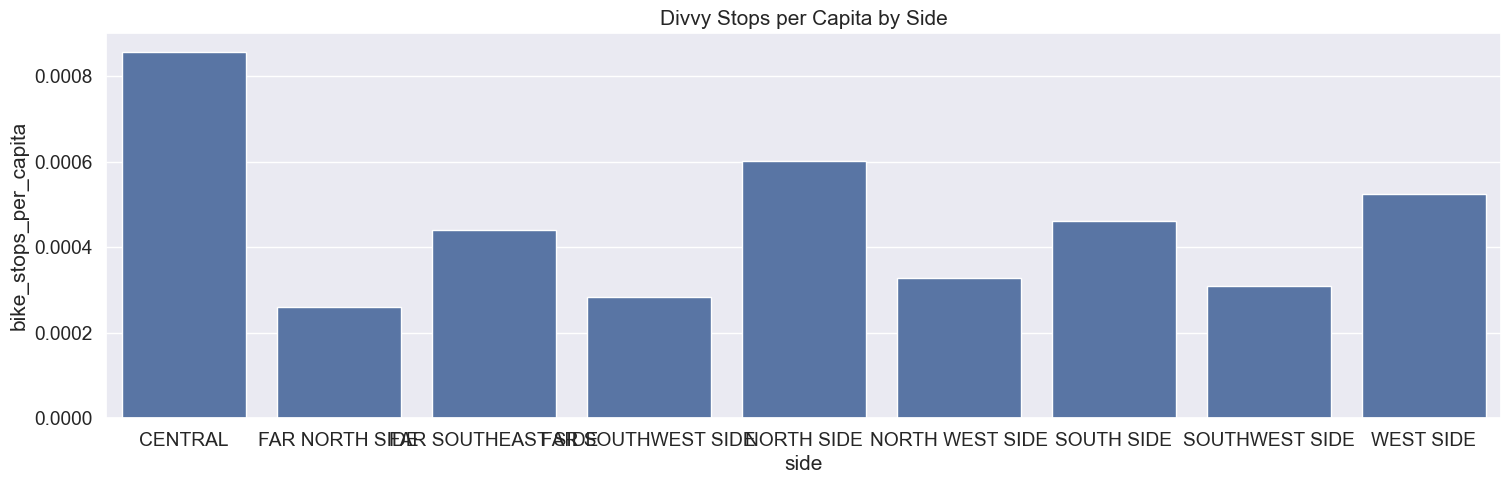

In [272]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Divvy Stops per Capita by Side')
sns.barplot(x='side', y='bike_stops_per_capita', data=side_data);

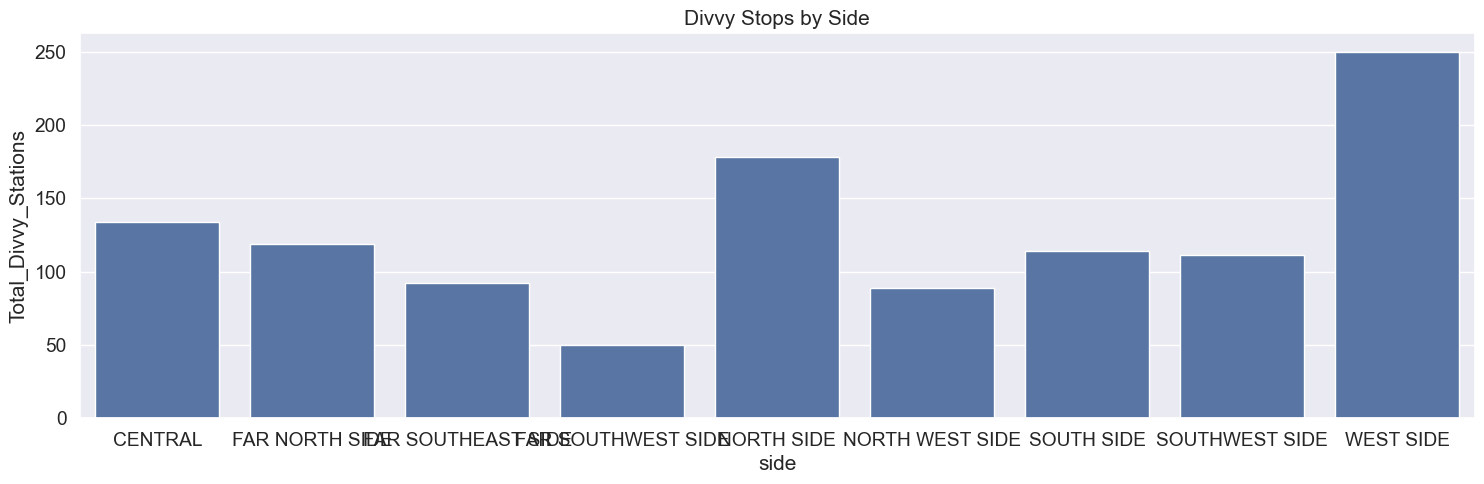

In [273]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Divvy Stops by Side')
sns.barplot(x='side', y='Total_Divvy_Stations', data=side_data);

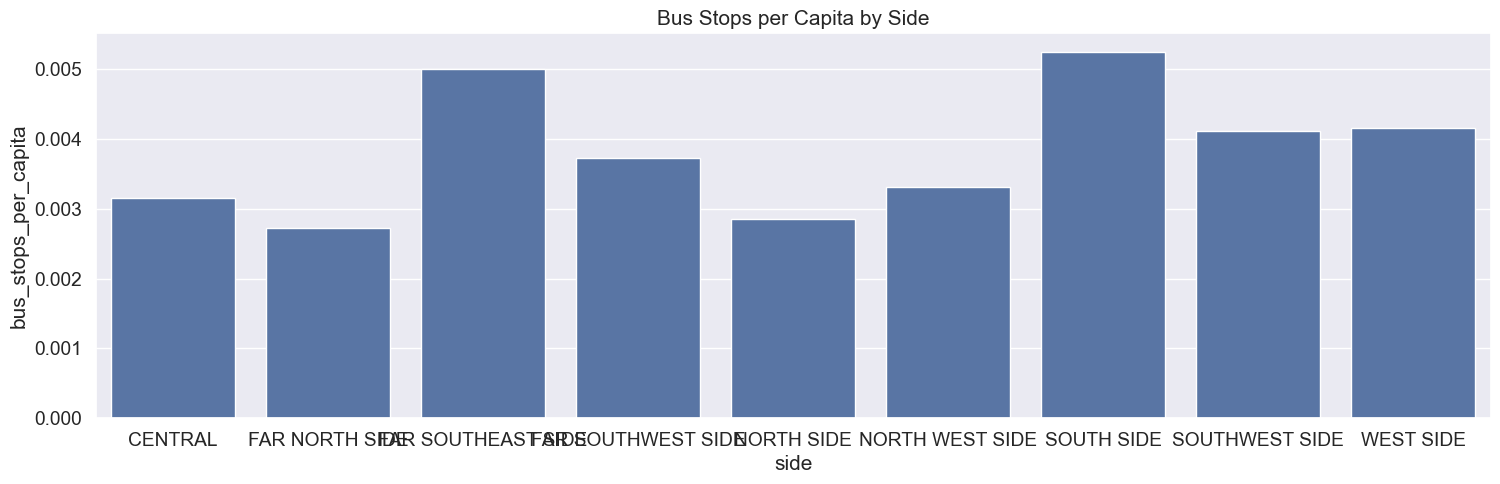

In [274]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Bus Stops per Capita by Side')
sns.barplot(x='side', y='bus_stops_per_capita', data=side_data);

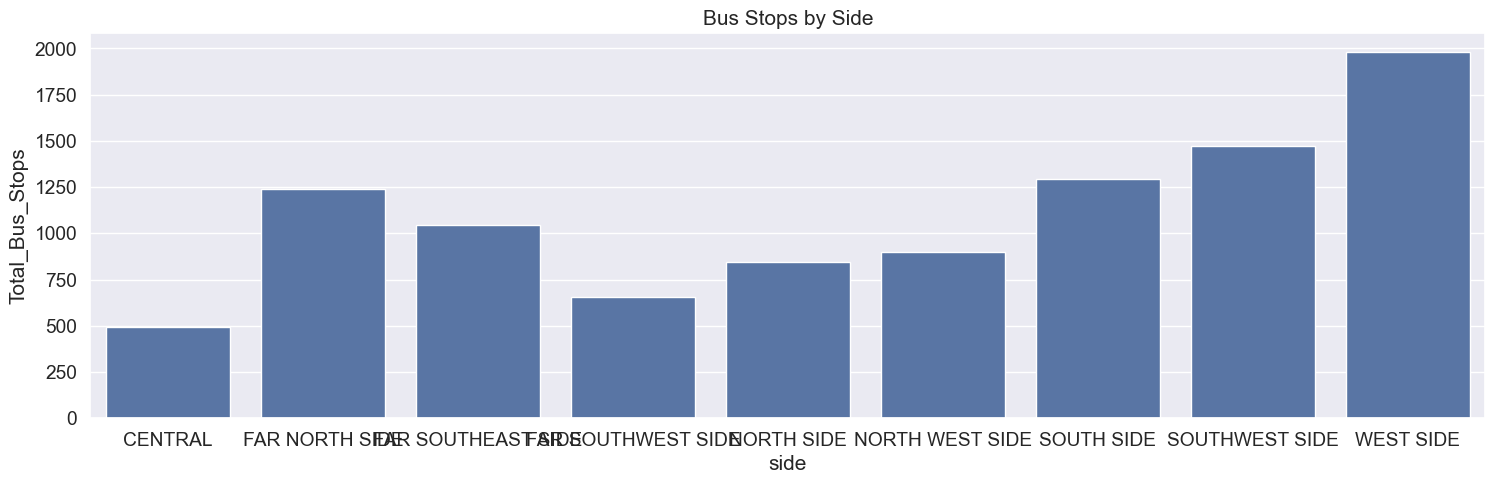

In [275]:
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Bus Stops by Side')
sns.barplot(x='side', y='Total_Bus_Stops', data=side_data);

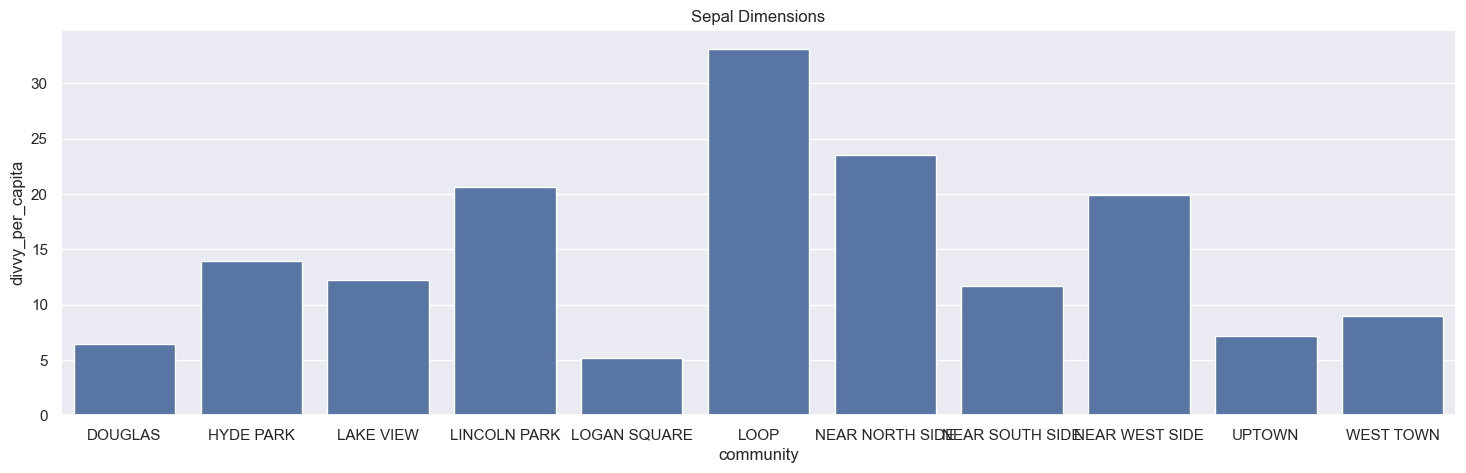

In [276]:
merged_over_5 = merged[merged['divvy_per_capita']>5]

sns.set()
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Sepal Dimensions')
sns.barplot(x='community', y='divvy_per_capita', data=merged_over_5);

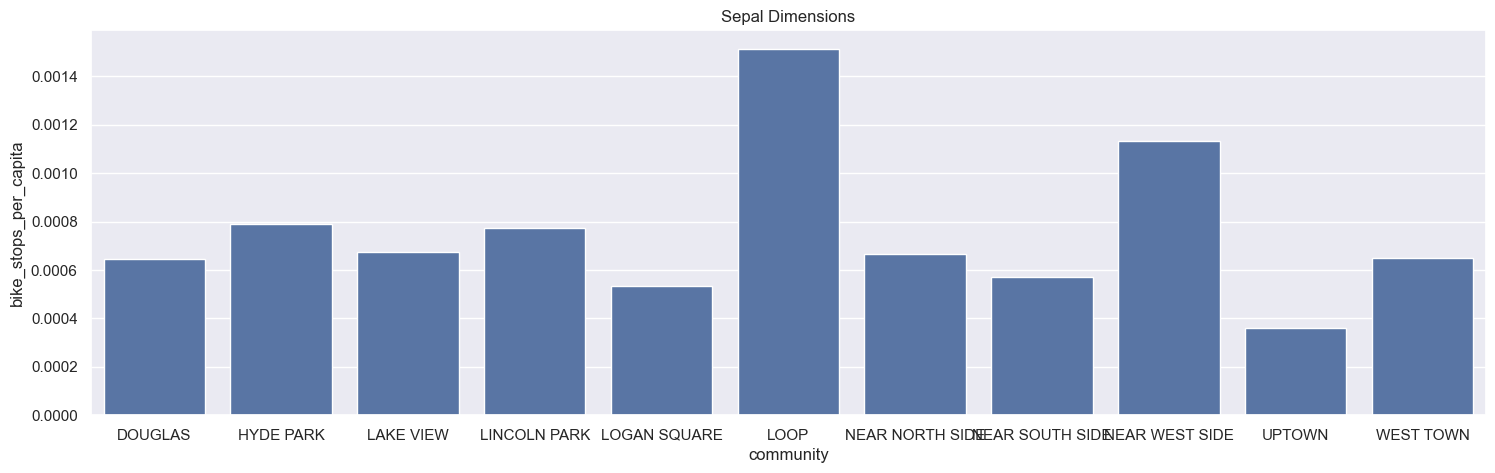

In [277]:
merged_over_5 = merged[merged['divvy_per_capita']>5]

sns.set()
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Sepal Dimensions')
sns.barplot(x='community', y='bike_stops_per_capita', data=merged_over_5);

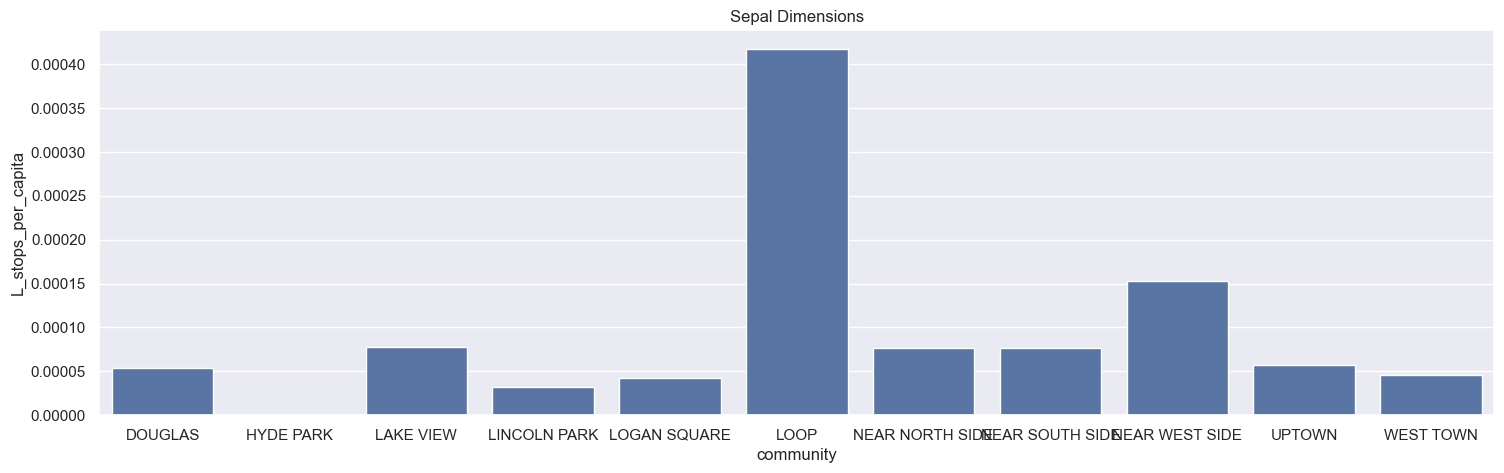

In [278]:
merged_over_5 = merged[merged['divvy_per_capita']>5]

sns.set()
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Sepal Dimensions')
sns.barplot(x='community', y='L_stops_per_capita', data=merged_over_5);

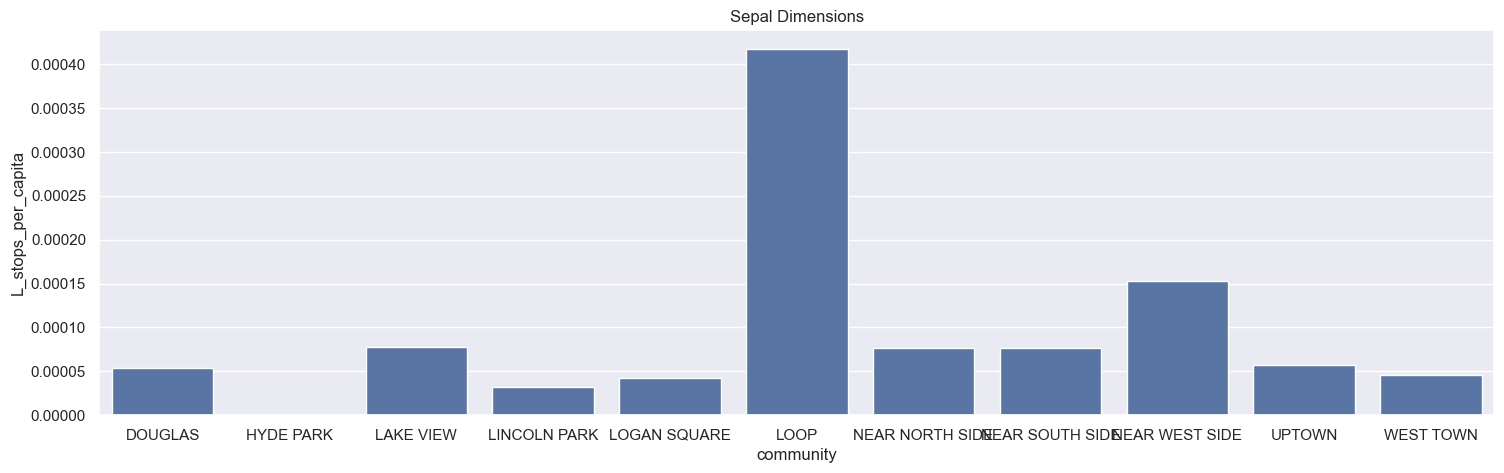

In [279]:
merged_over_5 = merged[merged['divvy_per_capita']>5]

sns.set()
plt.figure(figsize=(18, 5))
x = np.random.normal(size=1)
plt.title('Sepal Dimensions')
sns.barplot(x='community', y='L_stops_per_capita', data=merged_over_5);

### Analysis 1
*By \<Name of person doing the analysis>*

### Analysis 2
*By \<Name of person doing the analysis>*

### Analysis 3
*By \<Name of person doing the analysis>*

### Analysis 4
*By \<Name of person doing the analysis>*

## Other sections

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.**

Put each model in a section of its name and mention the name of the team-member tuning the model. Below is an example:

## Conclusions and Recommendations to stakeholder(s)

You may or may not have code to put in this section. Delete this section if it is irrelevant.